<a href="https://colab.research.google.com/github/ehas1/Statistical-Bias-in-ML/blob/main/LIME_and_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
! pip install lime
import lime.lime_tabular
import shap
! pip install scikit-learn
from sklearn.decomposition import PCA
import xgboost as xgb
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
import os
import glob
import joblib
from pathlib import Path
import requests
from io import StringIO

# Visualization Settings
sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Global Configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=82b2f8dc950d6007c139c52e588705d16e67b97991790ca2e357972ec6c71c7c
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
# Storage and Model Loading Setup
def setup_storage():
    """Set up storage access for model files."""
    # First try the local COMPAS_models directory in the current working directory
    models_dir = os.path.join(os.getcwd(), 'COMPAS_models')

    if not os.path.exists(models_dir):
        # Try home directory
        models_dir = os.path.join(os.path.expanduser('~'), 'Desktop/OAIP/Statistical-Bias-in-ML/COMPAS_models')

    # Create the models directory if it doesn't exist
    if not os.path.exists(models_dir):
        os.makedirs(models_dir)
        print(f"Created models directory at {models_dir}")

    print(f"Using models directory: {models_dir}")
    return models_dir

def find_latest_model(pattern: str, models_dir: str = None) -> str:
    """Find the most recent model file matching the given pattern."""
    # Try multiple possible paths
    colab_path = "/content/gdrive/MyDrive/COMPAS_models"
    local_path = os.path.join(os.path.expanduser('~'), 'COMPAS_models')
    current_dir_path = os.path.join(os.getcwd(), 'COMPAS_models')

    # Use provided models_dir, or try all possible paths
    search_paths = [p for p in [models_dir, colab_path, local_path, current_dir_path] if p]

    print(f"\nSearching for pattern: {pattern}")
    print("Checking directories:")

    for path in search_paths:
        print(f"Checking {path}...")
        if os.path.exists(path):
            print(f"Directory exists: {path}")
            # List all files in directory
            print("Files in directory:")
            for f in os.listdir(path):
                print(f"  - {f}")

            # Try to find matching files
            full_pattern = os.path.join(path, pattern)
            files = glob.glob(full_pattern)
            if files:
                print(f"Found files matching {pattern}:")
                for f in files:
                    print(f"  - {f}")
                latest = max(files, key=os.path.getctime)
                print(f"Selected latest file: {latest}")
                # Check if it's a metadata file
                if 'metadata' in latest:
                    print("Warning: Selected file is a metadata file, skipping...")
                    continue
                return latest
        else:
            print(f"Directory does not exist: {path}")

    raise FileNotFoundError(f"No model files found matching pattern: {pattern}")

def load_all_models() -> tuple:
    """Load all models including bias-specific decision trees."""
    try:
        models_dir = setup_storage()
        # Load bias-specific decision tree models
        sex_bias_model_path = find_latest_model('sex_bias_decision_tree_model_*[!metadata].joblib')
        racial_bias_model_path = find_latest_model('racial_bias_decision_tree_model_*[!metadata].joblib')

        # Try to find XGBoost model with different possible extensions
        try:
            xgb_model_path = find_latest_model('xgboost_model_*[!metadata].ubj')
        except FileNotFoundError:
            try:
                xgb_model_path = find_latest_model('xgboost_model_*[!metadata].json')
            except FileNotFoundError:
                xgb_model_path = find_latest_model('xgboost_model_*[!metadata].*')

        nn_model_path = find_latest_model('neural_network_model_*.keras')

        print("Loading models from:")
        print(f"Sex Bias Decision Tree: {sex_bias_model_path}")
        print(f"Racial Bias Decision Tree: {racial_bias_model_path}")
        print(f"XGBoost: {xgb_model_path}")
        print(f"Neural Network: {nn_model_path}")

        # Load decision tree models
        sex_bias_model = joblib.load(sex_bias_model_path)
        racial_bias_model = joblib.load(racial_bias_model_path)
        print("Successfully loaded bias-specific decision tree models")

        # Load XGBoost model
        try:
            wrapped_xgb = xgb.XGBClassifier(
                objective='binary:logistic',
                use_label_encoder=False
            )
            wrapped_xgb.load_model(str(xgb_model_path))
            print("Successfully loaded XGBoost model")
        except Exception as e:
            print(f"Error loading XGBoost model: {str(e)}")
            try:
                print("Attempting alternative loading method...")
                booster = xgb.Booster()
                booster.load_model(str(xgb_model_path))
                wrapped_xgb = xgb.XGBClassifier(
                    objective='binary:logistic',
                    use_label_encoder=False
                )
                wrapped_xgb._Booster = booster
                wrapped_xgb.n_classes_ = 2
                print("Successfully loaded XGBoost model using alternative method")
            except Exception as e2:
                print(f"Alternative loading method also failed: {str(e2)}")
                raise

        # Load Neural Network model
        nn_model = load_model(nn_model_path)
        print("Successfully loaded Neural Network model")

        return sex_bias_model, racial_bias_model, wrapped_xgb, nn_model

    except Exception as e:
        print(f"Error loading models: {str(e)}")
        print("Please ensure the models are saved in either:")
        print("- Google Colab: /content/drive/MyDrive/COMPAS_models/")
        print(f"- Local: {os.path.join(os.path.expanduser('~'), 'COMPAS_models')}")
        raise

# Mount Google Drive to access models
from google.colab import drive
drive.mount('/content/gdrive')
print("Google Drive mounted.")


# Set up storage and update the global models directory
MODELS_DIR = setup_storage()

# Load all models
sex_bias_model, racial_bias_model, xgb_model, nn_model = load_all_models()

# Create models dictionary
models_dict = {
    'sex_bias_dt': sex_bias_model,
    'racial_bias_dt': racial_bias_model,
    'xgb': xgb_model,
    'nn': nn_model
}

Mounted at /content/gdrive
Google Drive mounted.
Created models directory at /root/Desktop/OAIP/Statistical-Bias-in-ML/COMPAS_models
Using models directory: /root/Desktop/OAIP/Statistical-Bias-in-ML/COMPAS_models
Using models directory: /root/Desktop/OAIP/Statistical-Bias-in-ML/COMPAS_models

Searching for pattern: sex_bias_decision_tree_model_*[!metadata].joblib
Checking directories:
Checking /content/gdrive/MyDrive/COMPAS_models...
Directory exists: /content/gdrive/MyDrive/COMPAS_models
Files in directory:
  - decision_tree_model_20250806_005108.joblib
  - decision_tree_model_20250806_005108_metadata.json
  - racial_bias_decision_tree_model_20251030_203548.joblib
  - racial_bias_decision_tree_model_20251030_203548_metadata.json
  - sex_bias_decision_tree_model_20251030_203549.joblib
  - sex_bias_decision_tree_model_20251030_203549_metadata.json
  - xgboost_model_20251030_203553.joblib
  - xgboost_model_20251030_203553_metadata.json
  - neural_network_model_20251030_203859.keras
  - n

/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py:1124: UserWarning: [20:40:15] WARNING: /workspace/src/c_api/c_api.cc:1511: Unknown file format: `joblib`. Using UBJSON (`ubj`) as a guess.
  self.get_booster().load_model(fname)


Successfully loaded XGBoost model
Successfully loaded Neural Network model


In [ ]:
# Data Loading and Preprocessing Functions
def load_data(url="https://raw.githubusercontent.com/propublica/compas-analysis/refs/heads/master/cox-violent-parsed.csv"):
    """Load the COMPAS dataset from ProPublica's repository."""
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = pd.read_csv(StringIO(response.text))
        print(f"Successfully loaded data with shape: {data.shape}")
        return data
    except Exception as e:
        print(f"Error loading data: {str(e)}")
        raise

def preprocess_data(data):
    """Preprocess the COMPAS dataset for model interpretation."""
    # Print available columns for debugging
    print("Available columns in dataset:", data.columns.tolist())

    # Define required columns and their expected categories
    required_features = [
        'age',
        'c_charge_degree',
        'race',
        'sex',
        'priors_count',
        'juv_other_count',
        'juv_fel_count',
        'juv_misd_count',
        'decile_score'
    ]
    target = 'is_recid'

    # Define expected categories for categorical variables
    expected_categories = {
        'c_charge_degree': ['F', 'M'],  # Felony and Misdemeanor
        'race': ['African-American', 'Caucasian', 'Hispanic', 'Other'],
        'sex': ['Female', 'Male']
    }

    # Define the exact expected feature set for the neural network (14 features)
    expected_features = [
        # Numerical features
        'age', 'priors_count',
        # Charge degree features (all categories)
        'c_charge_degree_F', 'c_charge_degree_M',
        # Race features (all categories)
        'race_African-American', 'race_Caucasian', 'race_Hispanic', 'race_Other',
        # Sex features (all categories)
        'sex_Female', 'sex_Male',
        # Additional features that might be expected by the model
        'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'decile_score'
    ]

    # Validate required columns exist
    missing_cols = [col for col in required_features + [target] if col not in data.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    # Preprocessing pipeline
    print("\nPreprocessing steps:")

    # 1. Handle missing values
    print("1. Handling missing values...")
    for col in required_features:
        if data[col].isnull().any():
            if pd.api.types.is_numeric_dtype(data[col]):
                data[col].fillna(data[col].mean(), inplace=True)
            else:
                data[col].fillna(data[col].mode()[0], inplace=True)

    # 2. Convert categorical variables with controlled encoding
    print("2. Converting categorical variables...")
    data_processed = data[required_features].copy()

    # Ensure categories are mapped correctly
    data_processed['race'] = data_processed['race'].map(lambda x: 'Other' if x not in expected_categories['race'] else x)
    data_processed['c_charge_degree'] = data_processed['c_charge_degree'].map(lambda x: 'F' if x not in expected_categories['c_charge_degree'] else x)
    data_processed['sex'] = data_processed['sex'].map(lambda x: 'Male' if x not in expected_categories['sex'] else x)

    # First handle numerical features
    numerical_features = ['age', 'priors_count', 'decile_score']

    # Create a new DataFrame with just numerical features
    data_processed_new = pd.DataFrame()

    # Add numerical features
    for feature in numerical_features:
        if feature in data.columns:
            data_processed_new[feature] = data[feature]
        else:
            print(f"Warning: {feature} not found in data, filling with zeros")
            data_processed_new[feature] = 0

    # Create dummy variables for categorical features
    for cat_col, categories in expected_categories.items():
        # Create dummy variables
        dummies = pd.get_dummies(
            data_processed[cat_col],
            prefix=cat_col,
            prefix_sep='_'
        )

        # Ensure all expected categories exist
        for category in categories:
            col_name = f"{cat_col}_{category}"
            if col_name not in dummies.columns:
                dummies[col_name] = 0

        # Add to processed data
        data_processed_new = pd.concat([data_processed_new, dummies], axis=1)

    # Ensure all expected features are present and in correct order
    missing_features = set(expected_features) - set(data_processed_new.columns)
    if missing_features:
        print(f"Warning: Adding missing features: {missing_features}")
        for feature in missing_features:
            data_processed_new[feature] = 0

    # Reorder columns to match expected feature order
    data_processed = data_processed_new[expected_features]

    print("\nVerifying features:")
    print(f"Expected features: {len(expected_features)}")
    print(f"Actual features: {len(data_processed.columns)}")
    print("\nFeatures in processed data:")
    for i, col in enumerate(data_processed.columns, 1):
        print(f"{i}. {col}")

    # Print the expected feature set
    print("\nFeature set after preprocessing:")
    print(data_processed.columns.tolist())

    # 3. Normalize numerical features
    print("3. Normalizing numerical features...")
    numerical_features = ['age', 'priors_count', 'decile_score']
    for col in numerical_features:
        data_processed[col] = (data_processed[col] - data_processed[col].mean()) / data_processed[col].std()

    # 4. Split into features and target
    print("4. Preparing train-test split...")
    # Convert to float32 for neural network compatibility
    X = data_processed.astype(np.float32)
    y = data[target]

    # Print feature columns for verification
    print("\nFeature columns after preprocessing:")
    print(X.columns.tolist())
    print(f"Number of features: {len(X.columns)}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"\nPreprocessing complete:")
    print(f"Training set shape: {X_train.shape}")
    print(f"Test set shape: {X_test.shape}")

    return (X_train, y_train), (X_test, y_test)

# Load and preprocess data
print("Loading and preprocessing data...")
data = load_data()
(X_train, y_train), (X_test, y_test) = preprocess_data(data)
feature_names = X_train.columns.tolist()


Loading and preprocessing data...
Successfully loaded data with shape: (18316, 52)
Available columns in dataset: ['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1', 'start', 'end', 'event']

Preprocessing steps:
1. Handling missing values...
2. Converting categori

/tmp/ipython-input-86841138.py:69: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [ ]:
# Load models and verify compatibility
def verify_model_compatibility(X_sample, models):
    """Verify that the preprocessed data matches the expected input shapes of the models."""
    print("Verifying model compatibility...")

    # Get the number of features in the preprocessed data
    n_features = X_sample.shape[1]
    print(f"\nPreprocessed data has {n_features} features")
    print(f"Input data types:")
    for col in X_sample.columns:
        print(f"  {col}: {X_sample[col].dtype}")

    # Convert data to numpy array and ensure float32 type
    X_single = X_sample.values[:1].astype(np.float32)

    # Check Sex Bias Decision Tree model
    try:
        sex_bias_pred = models['sex_bias_dt'].predict_proba(X_single)
        print("✓ Sex Bias Decision Tree model compatible")
        print(f"Sex Bias model prediction shape: {sex_bias_pred.shape}")
    except Exception as e:
        print(f"✗ Sex Bias Decision Tree model error: {str(e)}")

    # Check Racial Bias Decision Tree model
    try:
        racial_bias_pred = models['racial_bias_dt'].predict_proba(X_single)
        print("✓ Racial Bias Decision Tree model compatible")
        print(f"Racial Bias model prediction shape: {racial_bias_pred.shape}")
    except Exception as e:
        print(f"✗ Racial Bias Decision Tree model error: {str(e)}")

    # Check XGBoost model
    try:
        xgb_pred = models['xgb'].predict_proba(X_single)
        print("✓ XGBoost model compatible")
        print(f"XGBoost prediction shape: {xgb_pred.shape}")
    except Exception as e:
        print(f"✗ XGBoost model error: {str(e)}")

    # Check Neural Network model
    try:
        # Get input shape from the model's input layer
        nn_input_shape = models['nn'].input_shape[1]
        print(f"\nNeural Network expects {nn_input_shape} features")
        if nn_input_shape != n_features:
            print(f"✗ Neural Network input shape mismatch: expected {nn_input_shape}, got {n_features}")
            print("\nFeature columns in preprocessed data:")
            print(X_sample.columns.tolist())
            raise ValueError(f"Neural Network expects {nn_input_shape} features but got {n_features}")

        # Try prediction with proper data type
        nn_pred = models['nn'].predict(X_single)
        print("✓ Neural Network model compatible")
        print(f"Neural Network prediction shape: {nn_pred.shape}")
    except Exception as e:
        print(f"✗ Neural Network model error: {str(e)}")
        print("\nDebug information:")
        print(f"Input shape: {X_single.shape}")
        print(f"Input data type: {X_single.dtype}")
        print(f"Model summary:")
        models['nn'].summary()
        raise

# Verify compatibility of all models
print("Verifying model compatibility...")
verify_model_compatibility(X_train, models_dict)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Verifying model compatibility...
Verifying model compatibility...

Preprocessed data has 14 features
Input data types:
  age: float32
  priors_count: float32
  c_charge_degree_F: float32
  c_charge_degree_M: float32
  race_African-American: float32
  race_Caucasian: float32
  race_Hispanic: float32
  race_Other: float32
  sex_Female: float32
  sex_Male: float32
  juv_fel_count: float32
  juv_misd_count: float32
  juv_other_count: float32
  decile_score: float32
✓ Sex Bias Decision Tree model compatible
Sex Bias model prediction shape: (1, 2)
✓ Racial Bias Decision Tree model compatible
Racial Bias model prediction shape: (1, 2)
✓ XGBoost model compatible
XGBoost prediction shape: (1, 2)

Neural Network expects 14 features
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
✓ Neural Network model compatible
Neural Network prediction shape: (1, 1)


In [ ]:
# LIME and SHAP Setup Functions
def setup_explainers(X_train, feature_names, models):
    """Set up LIME and SHAP explainers for all models."""
    # LIME: keep it simple; no unsupported kwargs in constructor
    lime_exp = lime.lime_tabular.LimeTabularExplainer(
        X_train.values,
        feature_names=feature_names,
        class_names=['No Recidivism', 'Recidivism'],
        mode='classification',
        discretize_continuous=False,           # data already scaled/one-hot
        kernel_width=0.75 * np.sqrt(X_train.shape[1]),
        verbose=False
    )

    # SHAP explainers
    def nn_predict_wrapper(x):
        pred = models['nn'].predict(x.astype(np.float32))
        if pred.ndim == 2 and pred.shape[1] == 1:   # sigmoid single logit
            return np.hstack([1 - pred, pred])
        return pred

    shap_exp = {}

    # Decision trees for bias diagnostics
    # Ensure explainer knows feature names
    shap_exp['sex_bias_dt'] = shap.TreeExplainer(models['sex_bias_dt'], feature_names=feature_names)
    shap_exp['racial_bias_dt'] = shap.TreeExplainer(models['racial_bias_dt'], feature_names=feature_names)

    # XGBoost: prefer TreeExplainer, fall back to model-agnostic if config parsing breaks
    try:
        # Ensure explainer knows feature names
        shap_exp['xgb'] = shap.TreeExplainer(models['xgb'], feature_names=feature_names)
    except Exception as e:
        print(f"Warning: TreeExplainer failed for XGBoost ({e}). Falling back to KernelExplainer.")
        # Fallback avoids ValueError: could not convert string to float: '[4.79E-1]'
        # Ensure background data retains feature names
        background = shap.sample(X_train, 100, random_state=42)
        # Ensure background data is a DataFrame with explicit columns for KernelExplainer
        if not isinstance(background, pd.DataFrame):
             background = pd.DataFrame(background, columns=feature_names)

        shap_exp['xgb'] = shap.KernelExplainer(
            lambda X: models['xgb'].predict_proba(X)[:, 1],
            background,
            link="logit"
        )

    # NN: use KernelExplainer on a small background sample
    # Ensure background data retains feature names and is a DataFrame
    background_nn = shap.sample(X_train, 100, random_state=42)
    if not isinstance(background_nn, pd.DataFrame):
         background_nn = pd.DataFrame(background_nn, columns=feature_names)

    shap_exp['nn'] = shap.KernelExplainer(
        nn_predict_wrapper,
        background_nn,
        link="logit"
    )

    return lime_exp, shap_exp


def plot_global_importance(X_train, lime_exp, shap_exp, models, feature_names, focus_bias=None):
    """
    Plot global feature importance using LIME and SHAP.

    focus_bias: 'sex', 'racial', or None.
    """
    sex_bias_features = ['sex_Female', 'sex_Male']
    racial_bias_features = ['race_African-American', 'race_Caucasian', 'race_Hispanic', 'race_Other']

    fig, axes = plt.subplots(2, 1, figsize=(15, 12))
    title = 'Global Feature Importance Comparison'
    if focus_bias:
        title += f' (Focus on {focus_bias.capitalize()} Bias)'
    fig.suptitle(title, fontsize=14)

    # SHAP importance
    shap_values = {}
    for name, explainer in shap_exp.items():
        if focus_bias == 'sex' and 'racial_bias' in name:
            continue
        if focus_bias == 'racial' and 'sex_bias' in name:
            continue

        # keep samples small for kernel-based explainers
        data = X_train if name not in ('nn',) else shap.sample(X_train, 100, random_state=42)
        # Ensure data passed to explainer is DataFrame with feature names
        if not isinstance(data, pd.DataFrame):
            data = pd.DataFrame(data, columns=feature_names)

        values = explainer.shap_values(data)
        # For binary classifiers some explainers return list [class0, class1]
        if isinstance(values, list):
            values = values[1]
        shap_values[name] = np.abs(np.asarray(values)).mean(0)

    shap_df = pd.DataFrame(shap_values, index=feature_names)
    ax0 = shap_df.plot(kind='bar', ax=axes[0])
    axes[0].set_title('SHAP Global Feature Importance')
    axes[0].set_xlabel('Features')
    axes[0].set_ylabel('Mean |SHAP value|')
    axes[0].legend(title='Model')

    # LIME importance
    X_sample = X_train.sample(n=min(100, len(X_train)), random_state=42)
    lime_model_keys = [k for k in models.keys()
                       if not focus_bias or
                       (focus_bias == 'sex' and 'racial_bias' not in k) or
                       (focus_bias == 'racial' and 'sex_bias' not in k)]
    lime_values = {name: np.zeros(len(feature_names)) for name in lime_model_keys}

    # robust feature name extraction: take token up to first space or comparator
    import re
    name_re = re.compile(r'^([^\s<>=]+)')

    for x in X_sample.values:
        for name in lime_model_keys:
            model = models[name]
            predict_fn = model.predict_proba if name != 'nn' else model.predict
            exp = lime_exp.explain_instance(
                x, predict_fn,
                num_features=len(feature_names),
                sample_around_instance=False
            )
            for feat, imp in exp.as_list():
                m = name_re.match(feat)
                if not m:
                    continue
                fname = m.group(1)
                if fname in feature_names:
                    idx = feature_names.index(fname)
                    lime_values[name][idx] += abs(imp)

    lime_df = pd.DataFrame(lime_values, index=feature_names)
    ax1 = lime_df.plot(kind='bar', ax=axes[1])
    axes[1].set_title('LIME Global Feature Importance')
    axes[1].set_xlabel('Features')
    axes[1].set_ylabel('Cumulative |importance|')
    axes[1].legend(title='Model')

    # Highlight bias features
    if focus_bias:
        highlight = sex_bias_features if focus_bias == 'sex' else racial_bias_features
        # bars are grouped by model, so just tint x-tick labels to avoid misaligned patch indexing
        for tick_label in axes[0].get_xticklabels():
            if tick_label.get_text() in highlight:
                tick_label.set_color('red')
                tick_label.set_fontweight('bold')
        for tick_label in axes[1].get_xticklabels():
            if tick_label.get_text() in highlight:
                tick_label.set_color('red')
                tick_label.set_fontweight('bold')

    plt.tight_layout()
    plt.show()


def analyze_bias_impact(X_test, y_test, models, feature_names, bias_type='sex'):
    """
    Analyze the impact of bias-related features on model predictions.
    bias_type: 'sex' or 'racial'
    """
    if bias_type == 'sex':
        bias_features = ['sex_Female', 'sex_Male']
        bias_model = models['sex_bias_dt']
        model_name = 'Sex Bias DT'
    else:
        bias_features = ['race_African-American', 'race_Caucasian', 'race_Hispanic', 'race_Other']
        bias_model = models['racial_bias_dt']
        model_name = 'Racial Bias DT'

    bias_indices = [feature_names.index(f) for f in bias_features]

    y_pred = bias_model.predict(X_test)

    from sklearn.metrics import classification_report, confusion_matrix
    print(f"\nModel Performance Analysis ({model_name}):")
    print("-" * 50)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=3))

    print(f"\nPrediction Distribution by {bias_type.capitalize()} Categories:")
    for feature in bias_features:
        feature_idx = feature_names.index(feature)
        subset_mask = X_test.iloc[:, feature_idx] == 1
        subset_pred = y_pred[subset_mask]
        subset_true = y_test[subset_mask]
        print(f"\n{feature} Analysis:")
        print(f"Total samples: {len(subset_pred)}")
        if len(subset_pred) > 0:
            print(f"Predicted recidivism rate: {(subset_pred == 1).mean():.3f}")
            print(f"Actual recidivism rate: {(subset_true == 1).mean():.3f}")
            print("\nConfusion Matrix:")
            print(confusion_matrix(subset_true, subset_pred))
        else:
            print("No samples in this subgroup.")

# Initialize the explainers
print("\nSetting up LIME and SHAP explainers...")
lime_exp, shap_exp = setup_explainers(X_train, feature_names, models_dict)
print("Explainers setup complete!")


Setting up LIME and SHAP explainers...
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step 
Explainers setup complete!



Analyzing random instances...

Instance 2833 (True label: No Recidivism)

Actual dataset values:
id                                                  1710
name                                         marc corley
first                                               marc
last                                              corley
compas_screening_date                         2013-04-01
sex                                                 Male
dob                                           1978-07-20
age                                                   37
age_cat                                          25 - 45
race                                           Caucasian
juv_fel_count                                          0
decile_score                                           2
juv_misd_count                                         0
juv_other_count                                        0
priors_count                                           0
days_b_screening_arrest                        

  0%|          | 0/1 [00:00<?, ?it/s]

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step


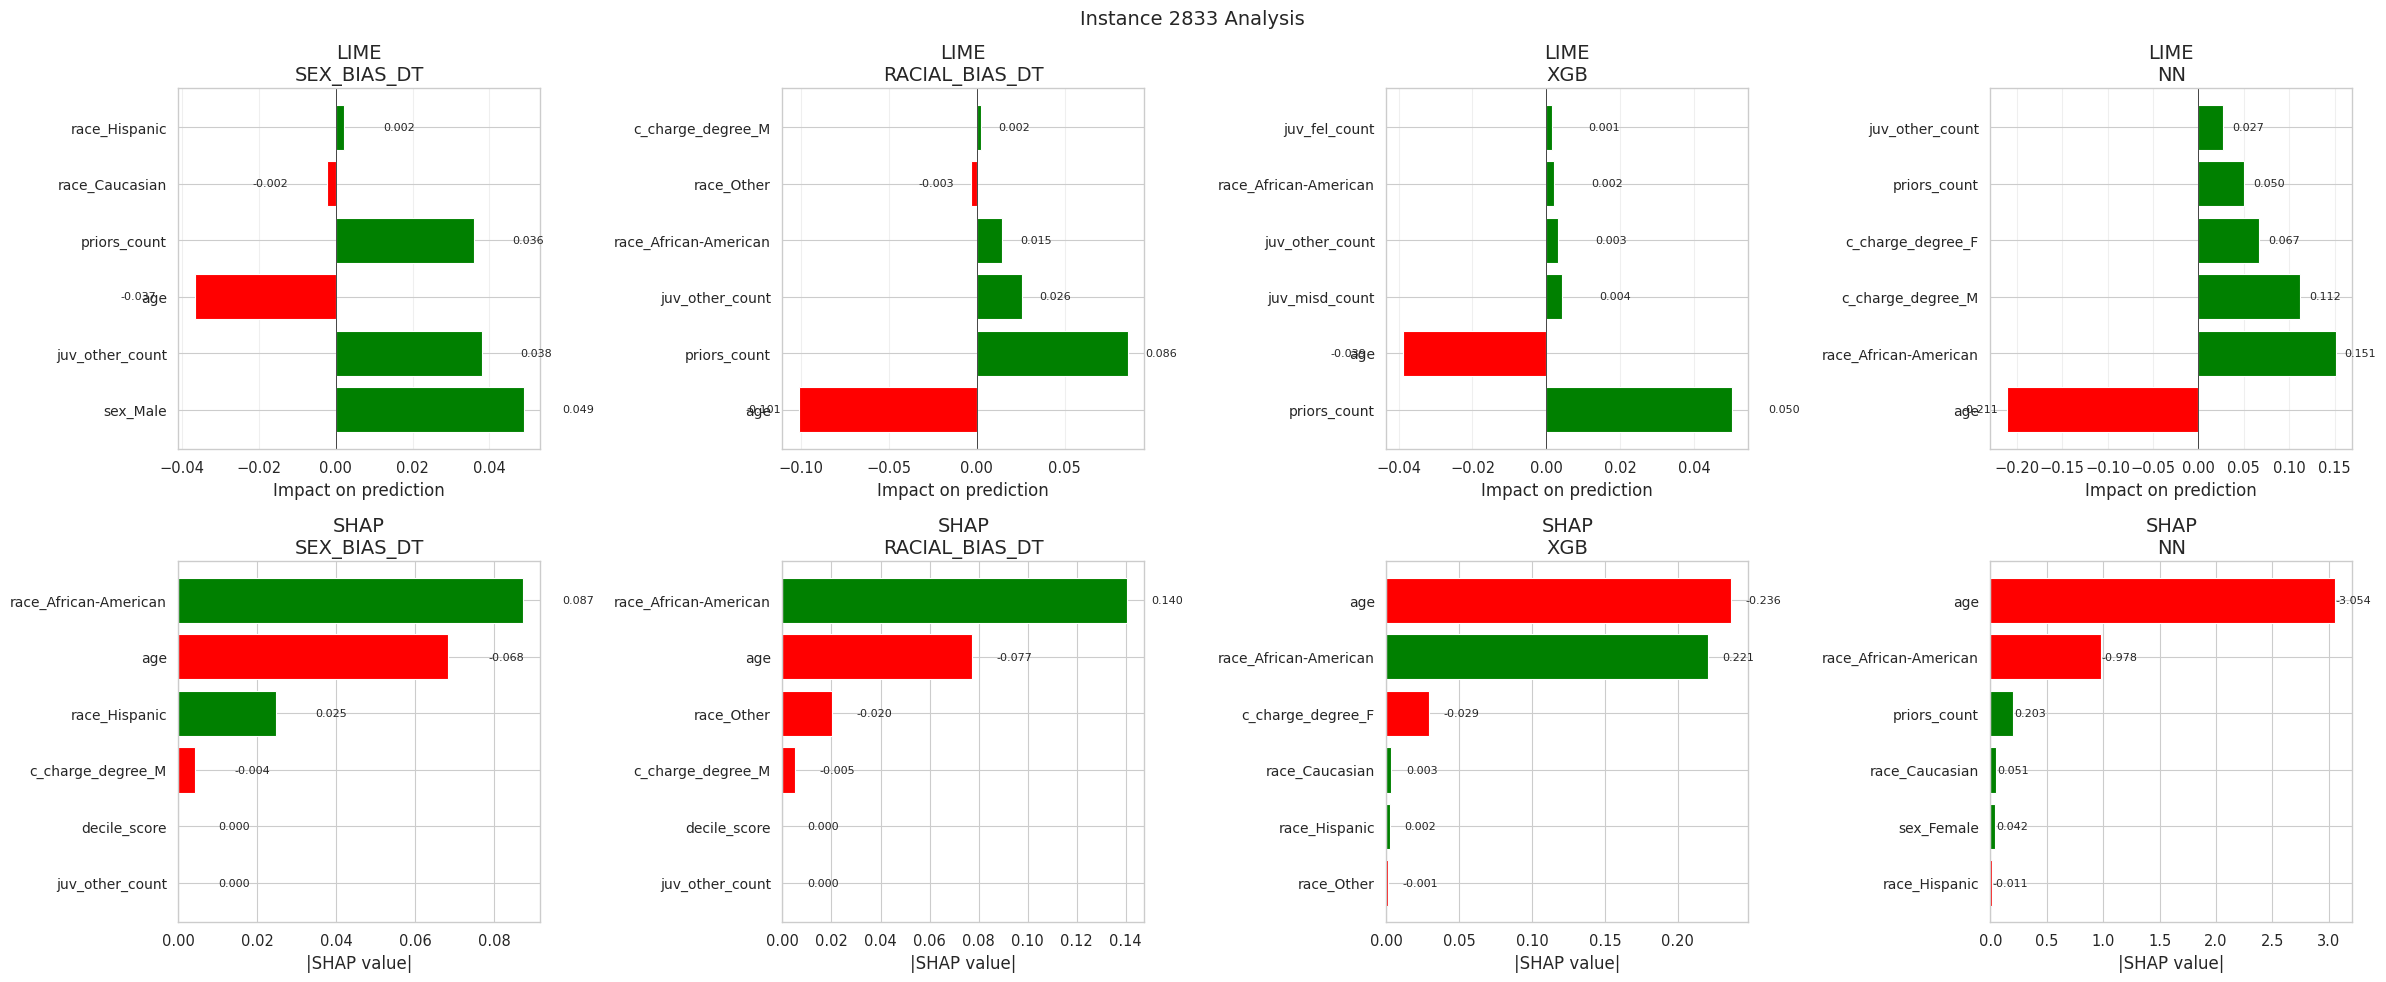


Instance 1607 (True label: No Recidivism)

Actual dataset values:
id                                                   959
name                                         alex cadeau
first                                               alex
last                                              cadeau
compas_screening_date                         2014-10-07
sex                                                 Male
dob                                           1995-08-02
age                                                   20
age_cat                                     Less than 25
race                                    African-American
juv_fel_count                                          0
decile_score                                           9
juv_misd_count                                         1
juv_other_count                                        1
priors_count                                           4
days_b_screening_arrest                             -1.0
c_jail_in            

  0%|          | 0/1 [00:00<?, ?it/s]

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


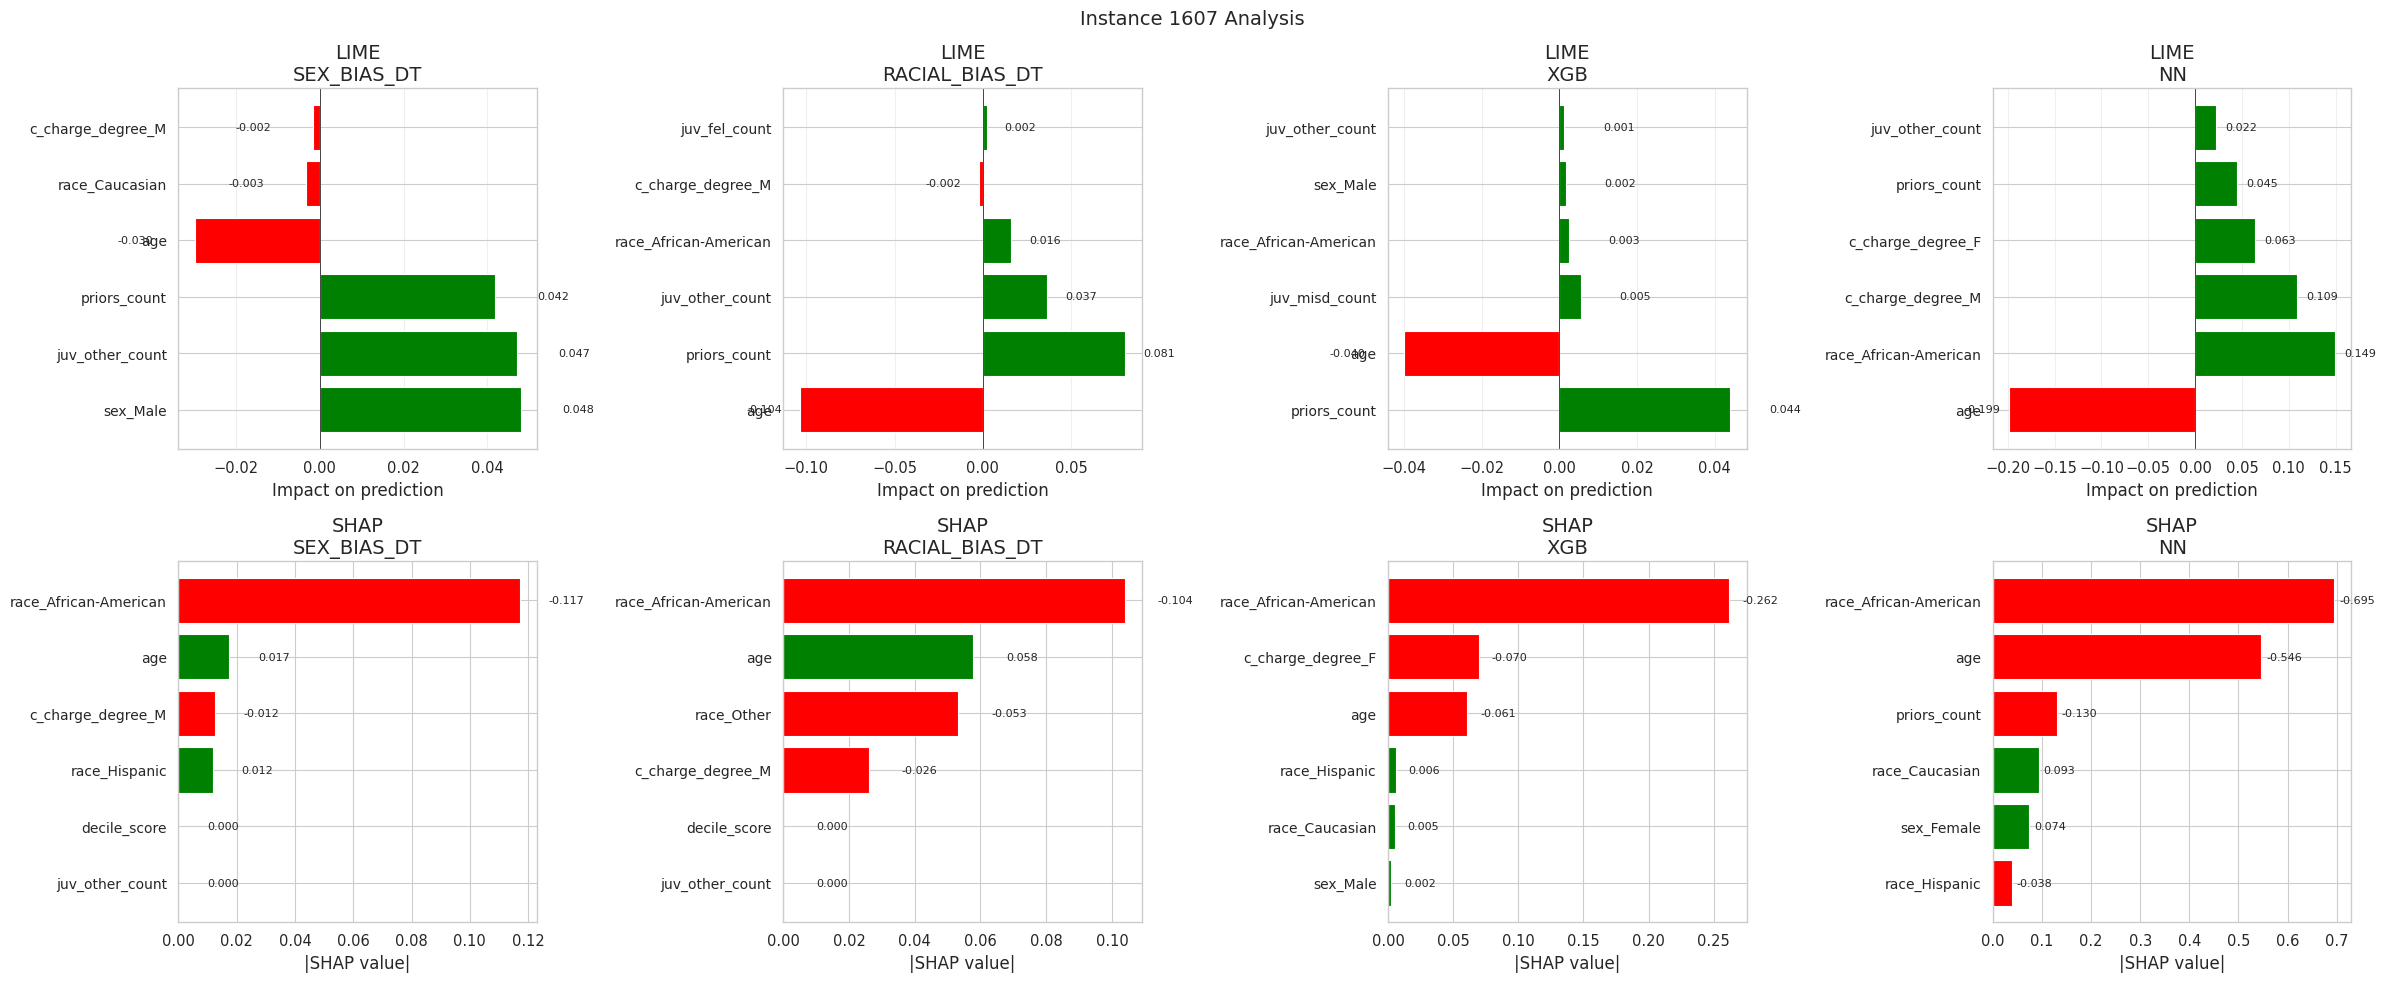


Instance 2397 (True label: Recidivism)

Actual dataset values:
id                                                  1449
name                                     willie brockman
first                                             willie
last                                            brockman
compas_screening_date                         2014-09-12
sex                                                 Male
dob                                           1978-08-11
age                                                   37
age_cat                                          25 - 45
race                                    African-American
juv_fel_count                                          0
decile_score                                           8
juv_misd_count                                         0
juv_other_count                                        0
priors_count                                           0
days_b_screening_arrest                             -1.0
c_jail_in               

  0%|          | 0/1 [00:00<?, ?it/s]

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


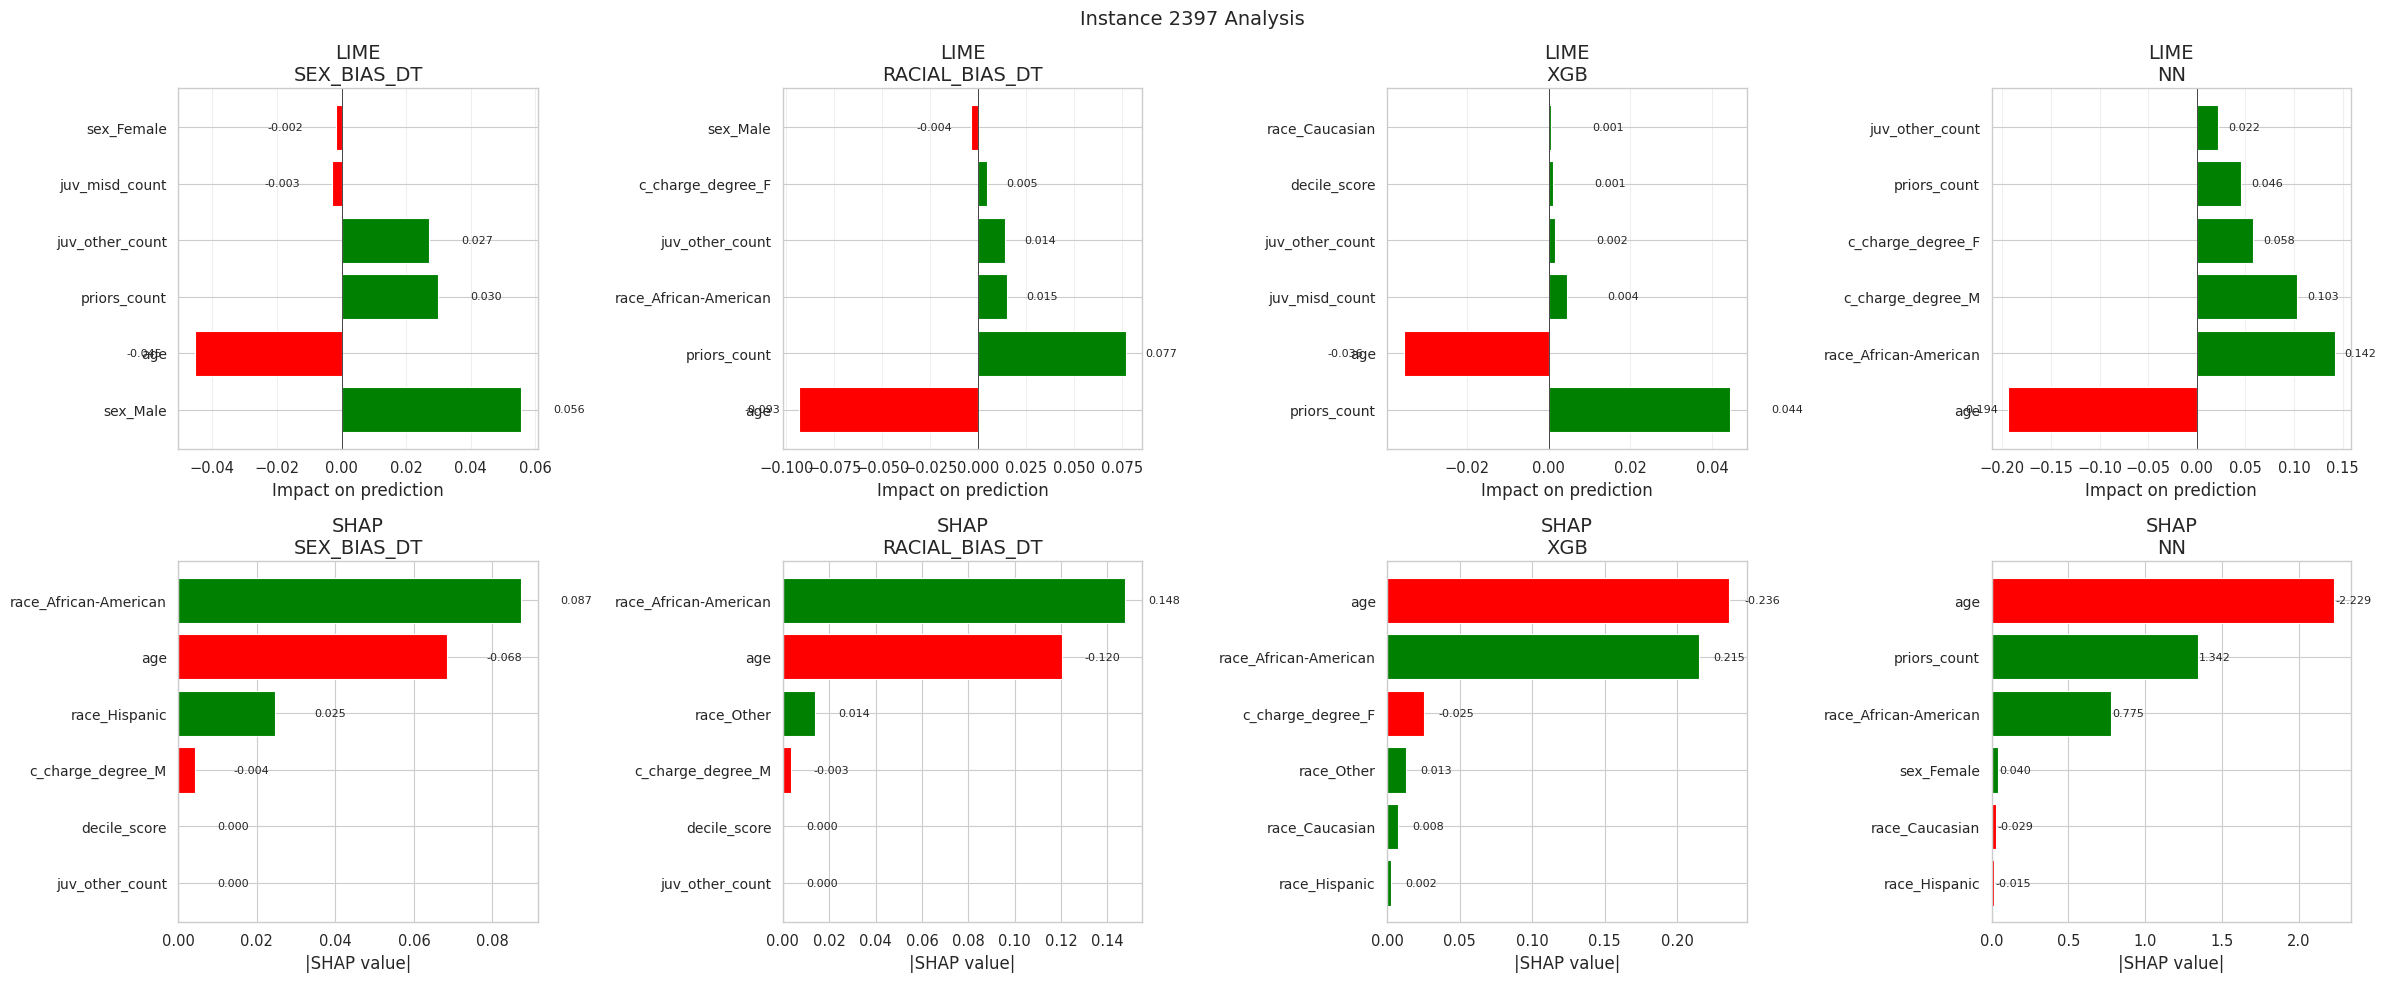


Instance 326 (True label: Recidivism)

Actual dataset values:
id                                                  176
name                                        coy daniels
first                                               coy
last                                            daniels
compas_screening_date                        2013-09-06
sex                                                Male
dob                                          1974-12-03
age                                                  41
age_cat                                         25 - 45
race                                   African-American
juv_fel_count                                         0
decile_score                                          9
juv_misd_count                                        1
juv_other_count                                       0
priors_count                                         10
days_b_screening_arrest                             0.0
c_jail_in                           2013-

  0%|          | 0/1 [00:00<?, ?it/s]

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


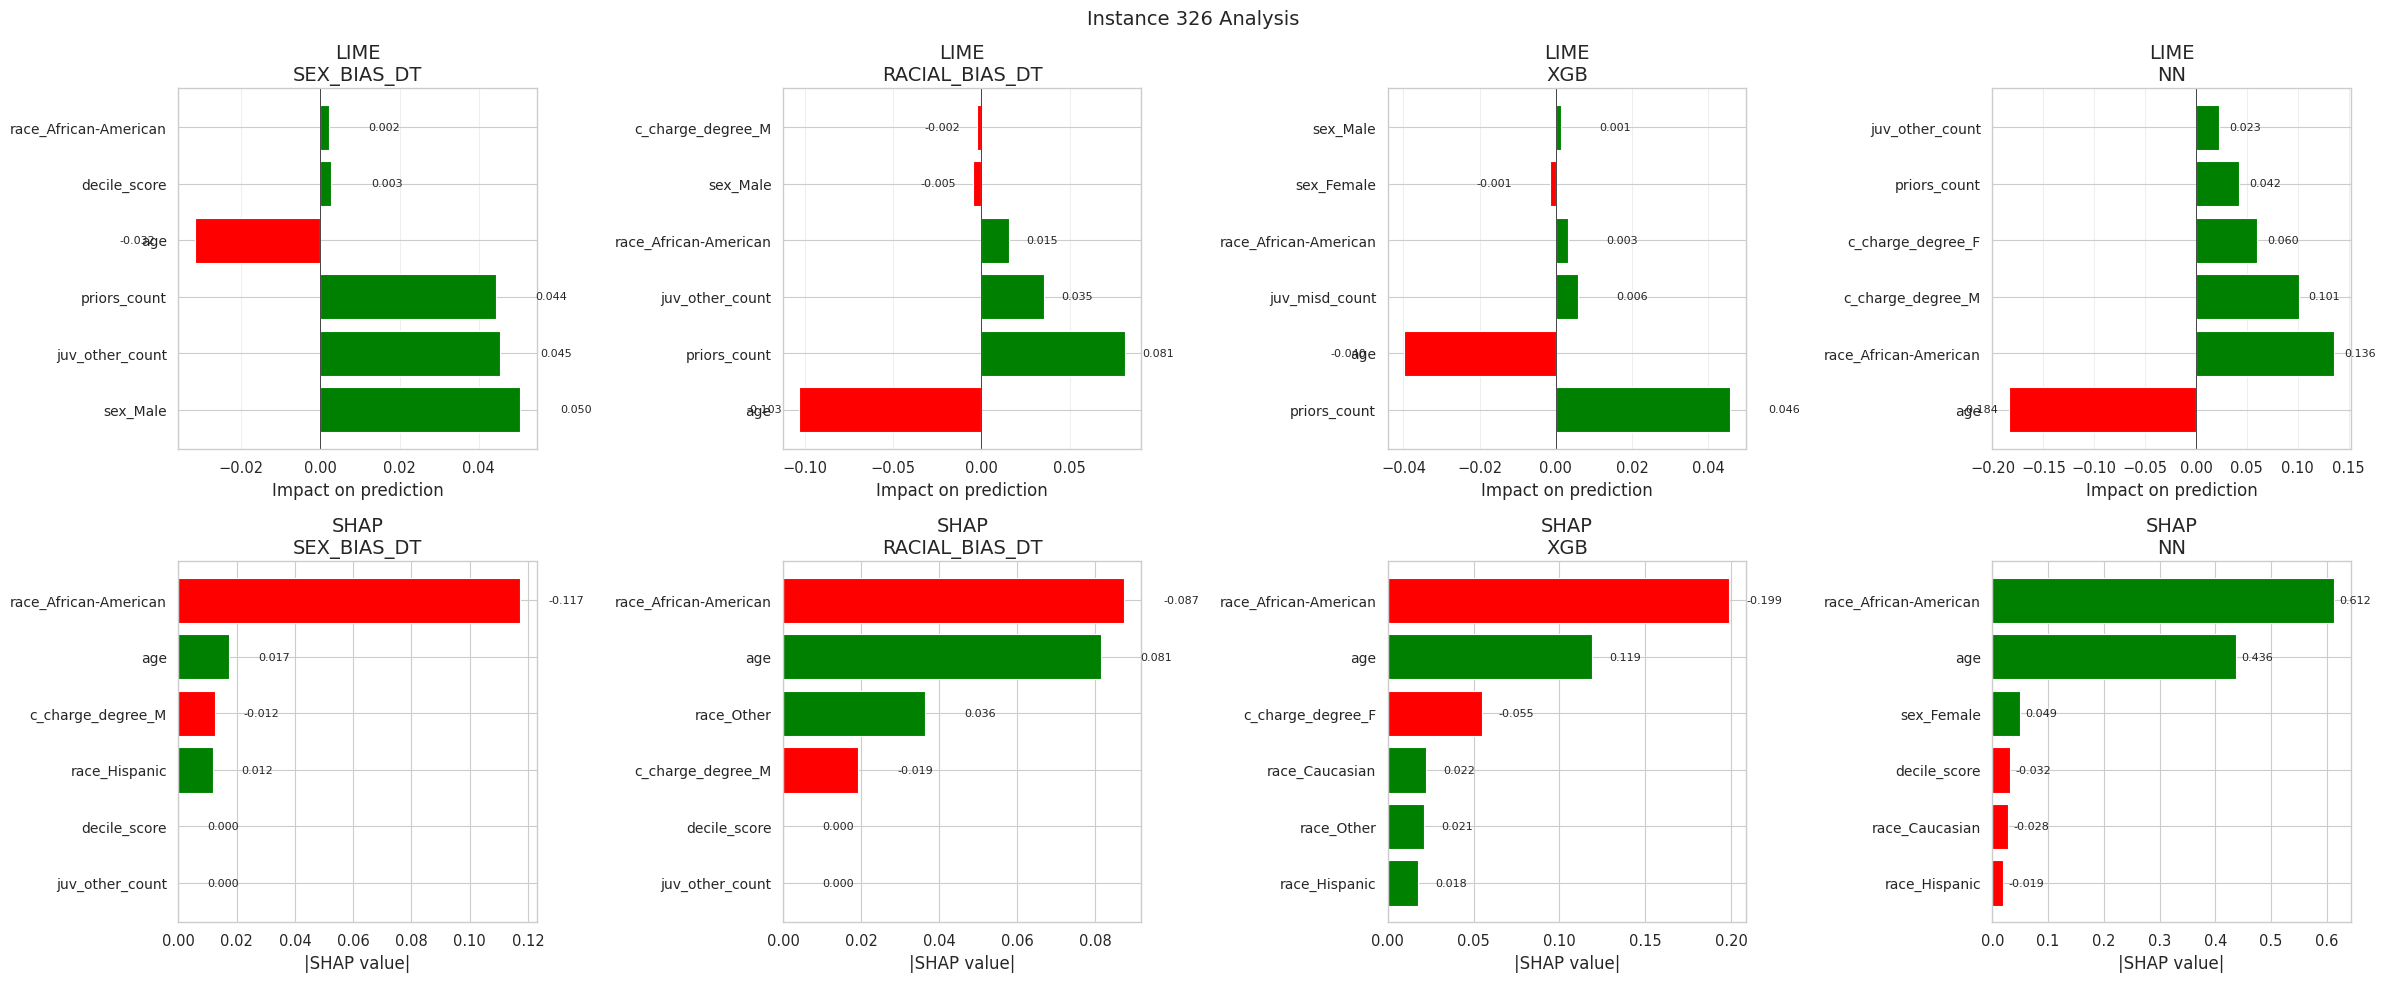


Instance 1586 (True label: No Recidivism)

Actual dataset values:
id                                           950
name                            michael williams
first                                    michael
last                                    williams
compas_screening_date                 2013-05-24
sex                                         Male
dob                                   1993-02-10
age                                           23
age_cat                             Less than 25
race                            African-American
juv_fel_count                                  0
decile_score                                  10
juv_misd_count                                 0
juv_other_count                                0
priors_count                                   4
days_b_screening_arrest                      0.0
c_jail_in                    2013-05-24 04:23:16
c_jail_out                   2013-05-26 08:24:37
c_case_number                      13007422CF10A
c_

  0%|          | 0/1 [00:00<?, ?it/s]

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


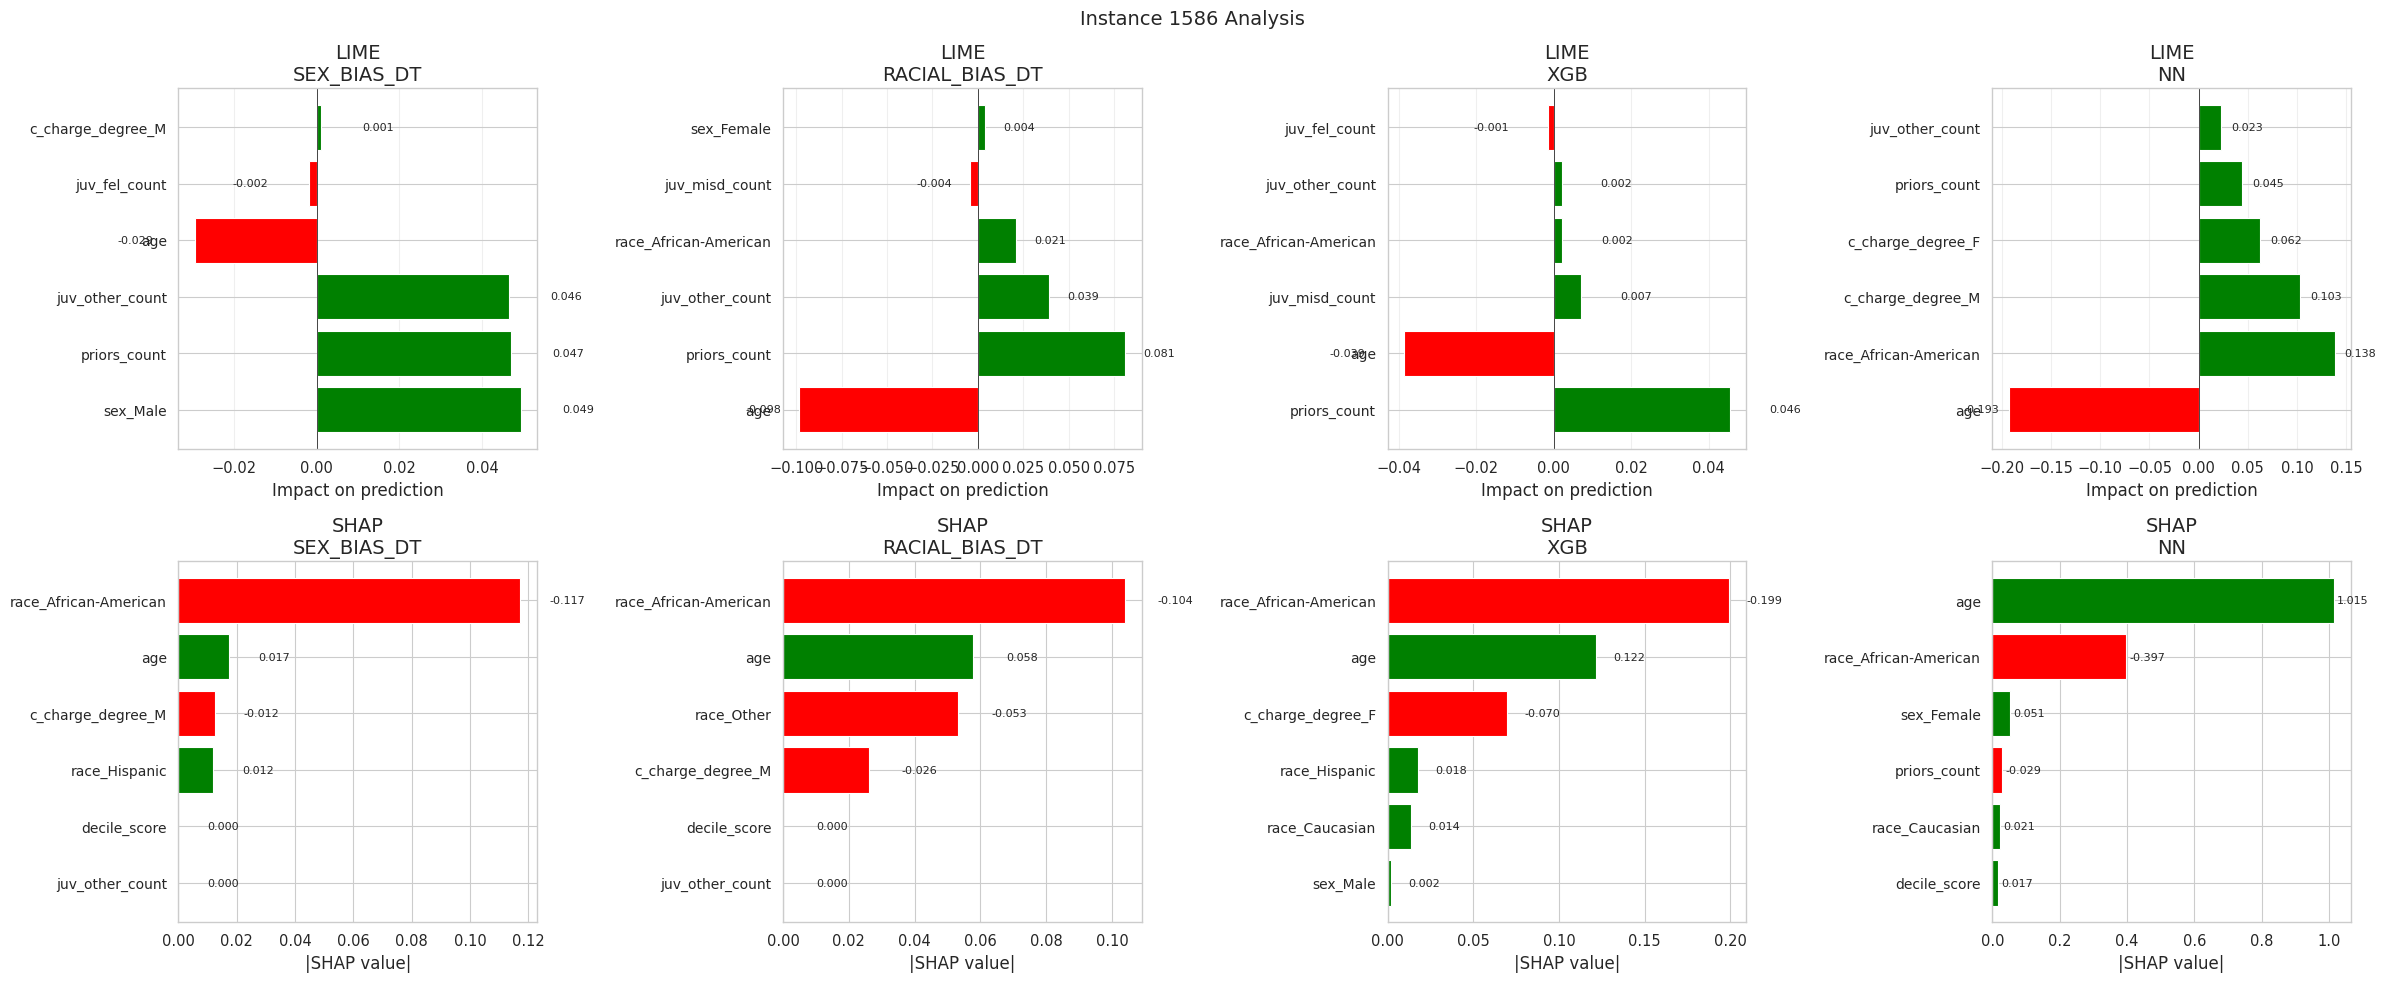

In [ ]:
def run_lime_shap_analysis(
    X_test, y_test, models_dict, feature_names, lime_exp, shap_exp,
    raw_data=None, n_instances=5, random_state=42
):
    """
    Runs per-instance LIME and SHAP analysis for 4 models:
    'sex_bias_dt', 'racial_bias_dt', 'xgb', 'nn'
    """

    # Choose instances
    rng = np.random.default_rng(random_state)
    n_instances = min(n_instances, len(X_test))
    random_indices = rng.choice(len(X_test), n_instances, replace=False)

    # Small helpers
    def as_df(X, cols):
        """Ensure model inputs have feature names to avoid sklearn warnings."""
        if isinstance(X, np.ndarray):
            return pd.DataFrame(X, columns=cols)
        # Already a DataFrame, ensure correct columns
        return pd.DataFrame(X, columns=cols) # Explicitly create new DF to enforce cols

    def get_model_feature_names(model, default_names):
        """Safely get feature names the model was trained on."""
        if hasattr(model, 'feature_names_in_'):
            return list(model.feature_names_in_)
        # Fallback for models without feature_names_in_ (e.g., older joblib loads)
        # Attempt to infer from expected features, but this is less reliable
        # print(f"Warning: Model {type(model).__name__} has no feature_names_in_. Using provided feature_names as fallback.")
        return default_names


    def proba_wrapper(model_key, all_feature_names):
        """Return a predict_proba-like function that accepts numpy and adds names."""
        model = models_dict[model_key]
        model_feature_names = get_model_feature_names(model, all_feature_names)

        if model_key == 'nn':
            # Return 2-column probabilities for LIME/SHAP
            def _fn(X):
                # Ensure input X (from LIME) is a DataFrame and aligned
                if isinstance(X,np.ndarray): X_aligned = as_df(X, all_feature_names)
                elif not isinstance(X,pd.DataFrame): X_aligned = as_df(np.array(X), all_feature_names)
                else: X_aligned = X.copy()

                # Reindex to model's expected features
                X_aligned = X_aligned.reindex(columns=model_feature_names, fill_value=0).values.astype(np.float32)

                out = model.predict(X_aligned)
                # If single output, treat as p1 and build [p0, p1]
                if out.ndim == 2 and out.shape[1] == 1:
                    p1 = out[:, 0]
                    p0 = 1.0 - p1
                    return np.column_stack([p0, p1])
                # If already 2 columns, return as-is
                return out
            return _fn
        else:
            # Tree or XGB style
            def _fn(X):
                # Ensure input X (from LIME) is a DataFrame and aligned
                if isinstance(X,np.ndarray): X_aligned = as_df(X, all_feature_names)
                elif not isinstance(X,pd.DataFrame): X_aligned = as_df(np.array(X), all_feature_names)
                else: X_aligned = X.copy()

                # Reindex to model's expected features
                X_aligned = X_aligned.reindex(columns=model_feature_names, fill_value=0)
                return models_dict[model_key].predict_proba(X_aligned)
            return _fn

    # Model order and axes
    model_keys = ['sex_bias_dt', 'racial_bias_dt', 'xgb', 'nn']
    model_keys = [k for k in model_keys if k in models_dict]

    print("\nAnalyzing random instances...")
    for idx in random_indices:
        instance = X_test.iloc[idx]
        true_label = y_test.iloc[idx]

        print("\n" + "=" * 80)
        print(f"Instance {idx} (True label: {'Recidivism' if true_label == 1 else 'No Recidivism'})")
        print("=" * 80)
        if raw_data is not None:
            print("\nActual dataset values:")
            try:
                if idx in raw_data.index:
                    print(raw_data.loc[idx])
                elif 'id' in raw_data.columns and 'id' in data.columns:
                    original_id = data.loc[idx, 'id']
                    raw_row = raw_data[raw_data['id'] == original_id]
                    if not raw_row.empty:
                        print(raw_row.iloc[0])
                    else:
                        print("Could not find matching data by ID.")
                else:
                    print("Index misalignment; skipping raw data display.")
            except Exception:
                print("Error displaying raw data.")


        instance_np = instance.values.reshape(1, -1).astype(np.float32)
        instance_df = as_df(instance_np, feature_names)

        preds = {}
        try:
            for name in model_keys:
                model = models_dict[name]
                model_feature_names = get_model_feature_names(model, feature_names)
                instance_aligned = instance_df.reindex(columns=model_feature_names, fill_value=0)

                if name == 'nn':
                    nn_out = model.predict(instance_aligned.values.astype(np.float32))
                    preds[name] = float(nn_out[0, 0]) if nn_out.shape[1] == 1 else float(nn_out[0, 1])
                else:
                    preds[name] = float(model.predict_proba(instance_aligned)[0, 1])

        except Exception as e:
            print(f"Error getting predictions for {name}: {e}")
            print(f"Instance DataFrame features: {instance_df.columns.tolist()}")
            raise

        # Print predictions
        print("\nPredictions:")
        print("-" * 40)
        for name in model_keys:
            if name in preds:
                print(f"{name.upper():15} : {preds[name]:.3f}")

        n_models = len(model_keys)
        fig, axes = plt.subplots(2, n_models, figsize=(6*n_models, 10))
        if n_models == 1:
            axes = np.array([[axes[0]], [axes[1]]])
        fig.suptitle(f'Instance {idx} Analysis', fontsize=14)

        for j, name in enumerate(model_keys):
            model = models_dict[name]
            model_feature_names = get_model_feature_names(model, feature_names)

            # LIME explanation
            predict_fn = proba_wrapper(name, feature_names)

            try:
                exp = lime_exp.explain_instance(
                    instance.values.astype(np.float32),
                    predict_fn,
                    num_features=6
                )
                exp_list = exp.as_list()

                if exp_list:
                    lime_feats, lime_vals = zip(*exp_list)
                    lime_vals = [float(v) for v in lime_vals]
                    colors = ['green' if v > 0 else 'red' for v in lime_vals]
                    y_pos = np.arange(len(lime_feats))

                    ax_lime = axes[0, j]
                    bars = ax_lime.barh(y_pos, lime_vals, align='center', color=colors)
                    ax_lime.set_yticks(y_pos)
                    ax_lime.set_yticklabels([str(x) for x in lime_feats], fontsize=10)
                    ax_lime.set_xlabel('Impact on prediction')
                    ax_lime.set_title(f'LIME\n{name.upper()}')
                    ax_lime.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
                    ax_lime.grid(True, axis='x', alpha=0.3)

                    for bar, value in zip(bars, lime_vals):
                        width = bar.get_width()
                        ax_lime.text(
                            width + (0.01 if width >= 0 else -0.01),
                            bar.get_y() + bar.get_height()/2,
                            f'{value:.3f}',
                            ha='left' if width >= 0 else 'right',
                            va='center', fontsize=8
                        )
                else:
                    print(f"\nLIME explanation list is empty for {name}.")
                    ax_lime = axes[0, j]
                    ax_lime.text(
                        0.5, 0.5, 'LIME values\nnot available',
                        ha='center', va='center', transform=ax_lime.transAxes
                    )
                    ax_lime.set_title(f'LIME\n{name.upper()}')

            except Exception as e:
                print(f"\nError calculating LIME values for {name}: {str(e)}")
                ax_lime = axes[0, j]
                ax_lime.text(
                    0.5, 0.5, 'LIME values\nnot available',
                    ha='center', va='center', transform=ax_lime.transAxes
                )
                ax_lime.set_title(f'LIME\n{name.upper()}')


            # SHAP values
            ax_shap = axes[1, j]
            try:
                if name == 'nn':
                    instance_aligned_shap_np = instance_df.values.astype(np.float32)
                    sv = shap_exp[name].shap_values(instance_aligned_shap_np)
                else:
                    instance_aligned_shap = instance_df.reindex(columns=get_model_feature_names(model, feature_names), fill_value=0)
                    sv = shap_exp[name].shap_values(instance_aligned_shap)

                # Extract SHAP values for positive class
                if isinstance(sv, list) and len(sv) > 1:
                    shap_arr = np.asarray(sv[1]).flatten()
                elif isinstance(sv, np.ndarray):
                    if sv.ndim == 3 and sv.shape[-1] == 2:
                        shap_arr = sv[0, :, 1]
                    elif sv.ndim == 2:
                        if sv.shape[1] == 2:
                            shap_arr = sv[:, 1]
                        else:
                            shap_arr = sv[0, :]
                    else:
                        shap_arr = sv.flatten()
                else:
                    shap_arr = np.asarray(sv).flatten()

                # Get feature names
                if hasattr(shap_exp[name], 'feature_names') and shap_exp[name].feature_names is not None:
                    shap_feature_names = list(shap_exp[name].feature_names)
                else:
                    shap_feature_names = feature_names

                if shap_arr.shape[0] != len(shap_feature_names):
                    raise ValueError(f"SHAP values length ({shap_arr.shape[0]}) != feature names length ({len(shap_feature_names)})")

                # Get top features by absolute SHAP value
                importance = np.abs(shap_arr)
                top_k_indices = np.argsort(importance)[::-1][:6]

                feat_sorted = [shap_feature_names[k] for k in top_k_indices]
                imp_sorted = importance[top_k_indices]
                shap_values_sorted = shap_arr[top_k_indices]
                colors_shap = ['green' if v > 0 else 'red' for v in shap_values_sorted]

                # Plot
                y_pos = np.arange(len(feat_sorted))
                bars_shap = ax_shap.barh(y_pos, imp_sorted, color=colors_shap)
                ax_shap.set_yticks(y_pos)
                ax_shap.set_yticklabels(feat_sorted, fontsize=10)
                ax_shap.set_title(f'SHAP\n{name.upper()}')
                ax_shap.set_xlabel('|SHAP value|')
                ax_shap.invert_yaxis()

                for bar, value in zip(bars_shap, shap_values_sorted):
                    width = bar.get_width()
                    ax_shap.text(
                        width + (0.01 if width >= 0 else -0.01),
                        bar.get_y() + bar.get_height()/2,
                        f'{value:.3f}',
                        ha='left' if width >= 0 else 'right',
                        va='center', fontsize=8
                    )

            except Exception as e:
                print(f"\nError calculating SHAP values for {name}: {str(e)}")
                ax_shap.text(
                    0.5, 0.5, 'SHAP values\nnot available',
                    ha='center', va='center', transform=ax_shap.transAxes
                )
                ax_shap.set_title(f'SHAP\n{name.upper()}')

        plt.tight_layout()
        plt.show()

run_lime_shap_analysis(
    X_test=X_test,
    y_test=y_test,
    models_dict=models_dict,
    feature_names=feature_names,
    lime_exp=lime_exp,
    shap_exp=shap_exp,
    raw_data=data,          # or None
    n_instances=5,
    random_state=42
)

 45/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


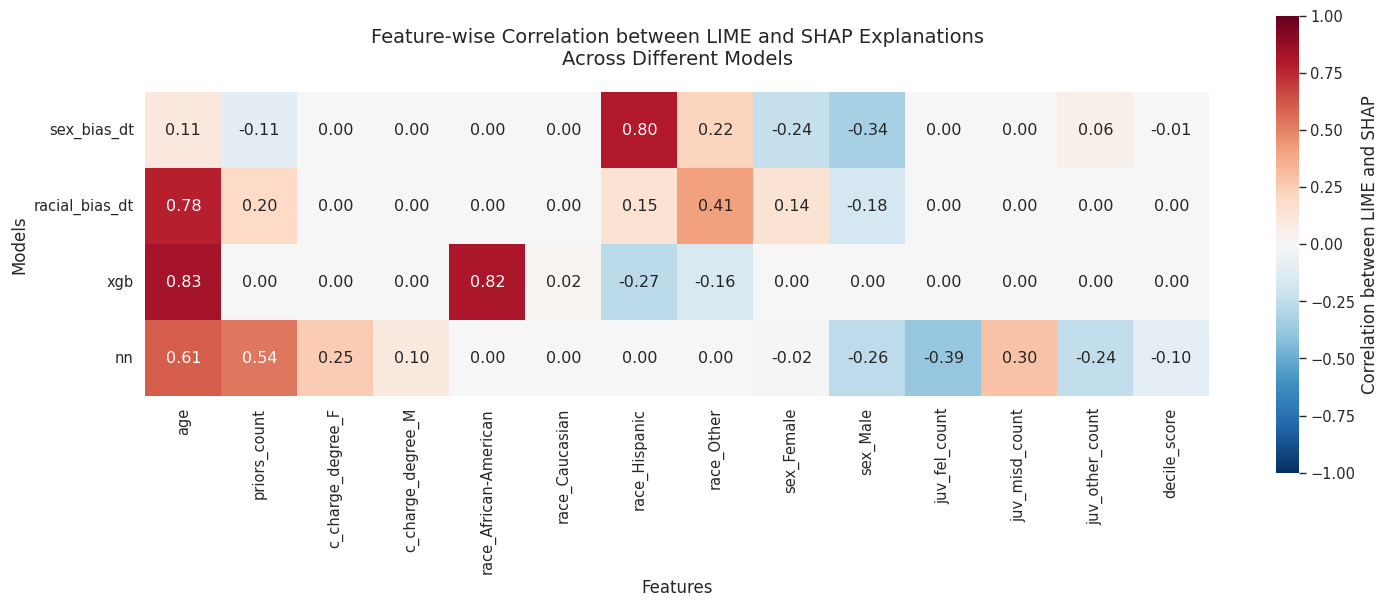


Summary of LIME vs SHAP Agreement by Feature:
--------------------------------------------------

Features ranked by consistency between LIME and SHAP:
age                       Mean correlation:  0.581 ± 0.329
race_African-American     Mean correlation:  0.204 ± 0.409 (Constant values in: SEX_BIAS_DT, RACIAL_BIAS_DT, NN)
race_Hispanic             Mean correlation:  0.171 ± 0.456 (Constant values in: NN)
priors_count              Mean correlation:  0.157 ± 0.283 (Constant values in: XGB)
race_Other                Mean correlation:  0.117 ± 0.250 (Constant values in: NN)
juv_misd_count            Mean correlation:  0.074 ± 0.148 (Constant values in: SEX_BIAS_DT, RACIAL_BIAS_DT, XGB)
c_charge_degree_F         Mean correlation:  0.063 ± 0.126 (Constant values in: SEX_BIAS_DT, RACIAL_BIAS_DT, XGB)
c_charge_degree_M         Mean correlation:  0.024 ± 0.048 (Constant values in: SEX_BIAS_DT, RACIAL_BIAS_DT, XGB)
race_Caucasian            Mean correlation:  0.005 ± 0.010 (Constant values in: 

In [ ]:
# Create correlation heatmap between LIME and SHAP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Initialize correlation matrices for each model
correlation_data = {}

def safe_correlation(x, y):
    """Calculate correlation with handling for constant arrays"""
    # Check if either array is constant
    if np.all(x == x[0]) or np.all(y == y[0]):
        if np.array_equal(x, y):  # If both arrays are identical constants
            return 1.0
        else:  # If only one array is constant or they're different constants
            return 0.0
    else:
        return stats.pearsonr(x, y)[0]

# Suppress specific warning about constant input
warnings.filterwarnings('ignore', category=stats.ConstantInputWarning)

# Select random instances for analysis
np.random.seed(42)  # for reproducibility
n_instances = 20
random_indices = np.random.choice(len(X_test), n_instances, replace=False)
test_instances = X_test.iloc[random_indices]

# Initialize storage for explanations
lime_explanations = {
    'sex_bias_dt': [], 'racial_bias_dt': [], 'xgb': [], 'nn': []
}
shap_explanations = {
    'sex_bias_dt': [], 'racial_bias_dt': [], 'xgb': [], 'nn': []
}

# Get explanations for each instance
for idx, instance in test_instances.iterrows():
    instance_reshaped = instance.values.reshape(1, -1).astype(np.float32)

    # Get LIME explanations
    for name, model in models_dict.items():
        if name == 'nn':
            predict_fn = lambda x: np.hstack([1 - model.predict(x.astype(np.float32)),
                                          model.predict(x.astype(np.float32))])
        else:
            predict_fn = model.predict_proba

        exp = lime_exp.explain_instance(
            instance.values.astype(np.float32),
            predict_fn,
            num_features=len(feature_names)
        )
        lime_values = dict(exp.as_list())
        lime_explanations[name].append([lime_values.get(f, 0) for f in feature_names])

    # Get SHAP explanations
    for name, explainer in shap_exp.items():
        shap_values = explainer.shap_values(instance_reshaped)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        shap_values = shap_values.reshape(-1)
        shap_explanations[name].append(shap_values)

# Convert explanations to numpy arrays
for name in models_dict.keys():
    lime_vals = np.abs(np.array(lime_explanations[name]))
    shap_vals = np.abs(np.array(shap_explanations[name]))

    # Calculate correlation for each feature
    correlations = []
    for i in range(len(feature_names)):
        corr = safe_correlation(lime_vals[:, i], shap_vals[:, i])
        correlations.append(corr)

    correlation_data[name] = correlations

# Create DataFrame with correlations
correlation_df = pd.DataFrame(correlation_data, index=feature_names)

# Create heatmap (transposed to be horizontal)
plt.figure(figsize=(15, 6))
sns.heatmap(correlation_df.T,  # Transpose to flip horizontal
            cmap='RdBu_r',  # Red-Blue diverging colormap
            center=0,       # Center the colormap at 0
            vmin=-1,       # Minimum correlation
            vmax=1,        # Maximum correlation
            annot=True,    # Show correlation values
            fmt='.2f',     # Format for correlation values
            square=True,   # Make cells square
            cbar_kws={'label': 'Correlation between LIME and SHAP'})

plt.title('Feature-wise Correlation between LIME and SHAP Explanations\nAcross Different Models', pad=20)
plt.xlabel('Features')
plt.ylabel('Models')
plt.tight_layout()
plt.show()

# Print summary statistics with additional information
print("\nSummary of LIME vs SHAP Agreement by Feature:")
print("-" * 50)

# Calculate mean correlation across models for each feature
mean_correlations = correlation_df.mean(axis=1)
std_correlations = correlation_df.std(axis=1)

# Sort features by average correlation
sorted_features = mean_correlations.sort_values(ascending=False)

print("\nFeatures ranked by consistency between LIME and SHAP:")
for feature in sorted_features.index:
    mean_corr = mean_correlations[feature]
    std_corr = std_correlations[feature]

    # Check if feature has any constant values
    constant_models = []
    for model in correlation_df.columns:
        lime_const = np.all(np.abs(lime_explanations[model])[:, feature_names.index(feature)] ==
                          np.abs(lime_explanations[model])[0, feature_names.index(feature)])
        shap_const = np.all(np.abs(shap_explanations[model])[:, feature_names.index(feature)] ==
                          np.abs(shap_explanations[model])[0, feature_names.index(feature)])
        if lime_const or shap_const:
            constant_models.append(model.upper())

    print(f"{feature:<25} Mean correlation: {mean_corr:6.3f} ± {std_corr:4.3f}", end="")
    if constant_models:
        print(f" (Constant values in: {', '.join(constant_models)})")
    else:
        print()

# Print model-wise statistics
print("\nModel-wise Agreement Statistics:")
print("-" * 50)
for model in correlation_df.columns:
    corrs = correlation_df[model]
    print(f"\n{model.upper()} Model:")
    print(f"Average correlation: {corrs.mean():.3f}")
    print(f"Correlation std: {corrs.std():.3f}")

    # Count features with constant values
    constant_features = []
    for feature in feature_names:
        lime_const = np.all(np.abs(lime_explanations[model])[:, feature_names.index(feature)] ==
                          np.abs(lime_explanations[model])[0, feature_names.index(feature)])
        shap_const = np.all(np.abs(shap_explanations[model])[:, feature_names.index(feature)] ==
                          np.abs(shap_explanations[model])[0, feature_names.index(feature)])
        if lime_const or shap_const:
            constant_features.append(feature)

    if constant_features:
        print(f"Features with constant values: {len(constant_features)}")
        print("Constant features:", ", ".join(constant_features))

    print(f"Features with highest agreement:")
    top_features = corrs.sort_values(ascending=False).head(3)
    for feat, corr in top_features.items():
        print(f"  {feat:<25} Correlation: {corr:.3f}")




Directional Flip Analysis
Analyzing demographic bias by testing both flip directions

Test Set Demographics:
  Total individuals in test set: 3664

Sex Distribution:
  Female: 670 (18.3%)
  Male: 2994 (81.7%)

Race Distribution:
  African-American: 1938 (52.9%)
  Caucasian: 1233 (33.7%)
  Hispanic: 290 (7.9%)
  Other: 203 (5.5%)

------------------------------------------------------------

Analyzing sex-based flips...
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Complete

Finding race pair with strongest effect...
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
16/16 ━

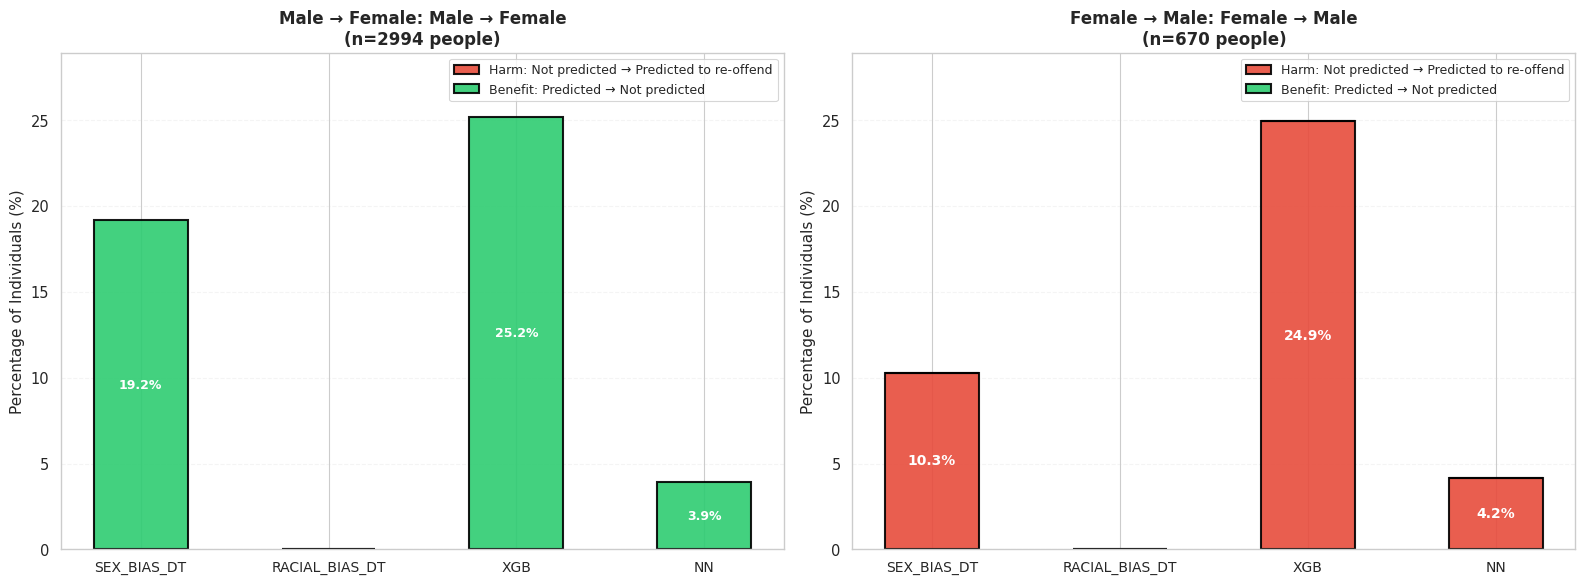

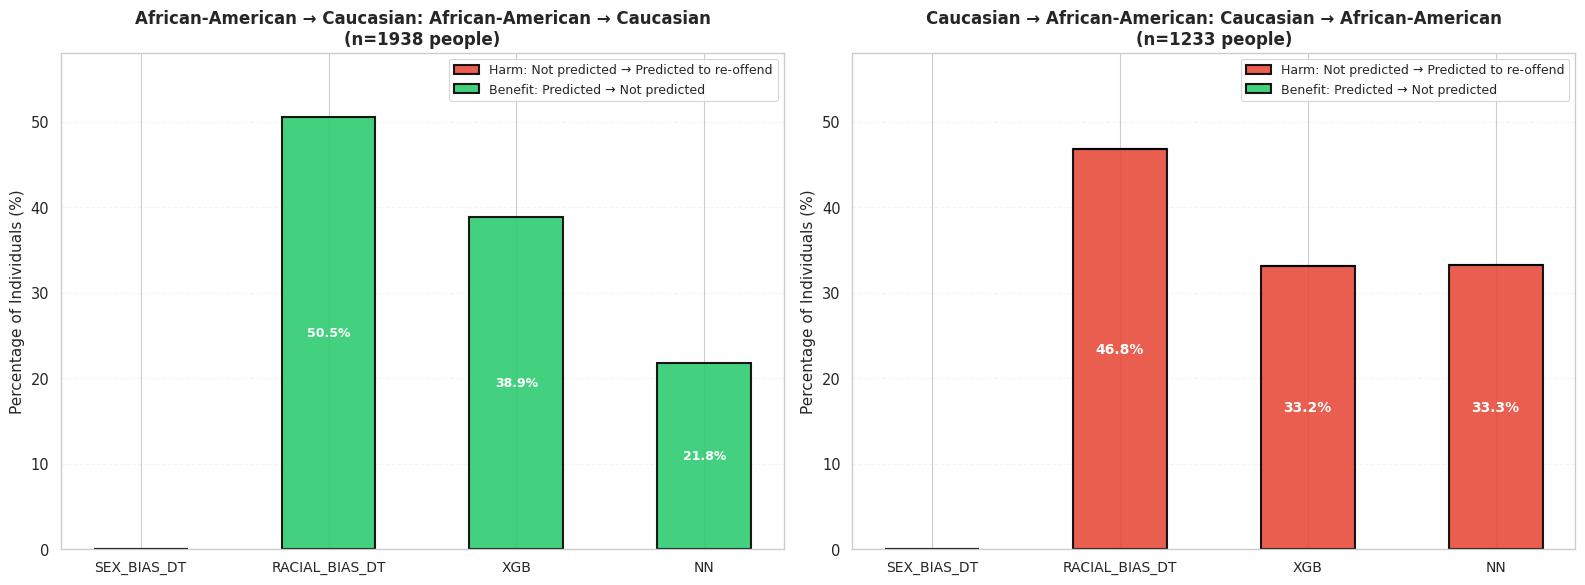


Directional Flip Analysis Results

Interpretation:
  HARM % = People who were NOT predicted to re-offend, but ARE after flip
  BENEFIT % = People who WERE predicted to re-offend, but are NOT after flip
  Avg Change = Average change in recidivism probability (percentage points)


Male → Female: Male → Female
Population sample: 2994 individuals



,Model,Direction,HARM,HARM %,BENEFIT,BENEFIT %,Avg Δ Probability
0,SEX_BIAS_DT,Male → Female,0,0.0%,574,19.2%,-7.35 pts
1,RACIAL_BIAS_DT,Male → Female,0,0.0%,0,0.0%,+0.00 pts
2,XGB,Male → Female,0,0.0%,753,25.2%,-1.42 pts
3,NN,Male → Female,0,0.0%,118,3.9%,-2.89 pts



Female → Male: Female → Male
Population sample: 670 individuals



,Model,Direction,HARM,HARM %,BENEFIT,BENEFIT %,Avg Δ Probability
0,SEX_BIAS_DT,Female → Male,69,10.3%,0,0.0%,+3.87 pts
1,RACIAL_BIAS_DT,Female → Male,0,0.0%,0,0.0%,+0.00 pts
2,XGB,Female → Male,167,24.9%,0,0.0%,+1.47 pts
3,NN,Female → Male,28,4.2%,0,0.0%,+3.33 pts



Key Findings:

Male → Female:
  Model with highest bias: SEX_BIAS_DT
  0 people (0.0%) newly predicted to re-offend
  Average probability increase: -7.35 percentage points
  Bias severity: LOW

Female → Male:
  Model with highest bias: XGB
  167 people (24.9%) newly predicted to re-offend
  Average probability increase: +1.47 percentage points
  Bias severity: SEVERE


Directional Flip Analysis Results

Interpretation:
  HARM % = People who were NOT predicted to re-offend, but ARE after flip
  BENEFIT % = People who WERE predicted to re-offend, but are NOT after flip
  Avg Change = Average change in recidivism probability (percentage points)


African-American → Caucasian: African-American → Caucasian
Population sample: 1938 individuals



,Model,Direction,HARM,HARM %,BENEFIT,BENEFIT %,Avg Δ Probability
0,SEX_BIAS_DT,African-American → Caucasian,0,0.0%,0,0.0%,+0.00 pts
1,RACIAL_BIAS_DT,African-American → Caucasian,0,0.0%,979,50.5%,-10.99 pts
2,XGB,African-American → Caucasian,0,0.0%,753,38.9%,-0.76 pts
3,NN,African-American → Caucasian,0,0.0%,422,21.8%,-20.85 pts



Caucasian → African-American: Caucasian → African-American
Population sample: 1233 individuals



,Model,Direction,HARM,HARM %,BENEFIT,BENEFIT %,Avg Δ Probability
0,SEX_BIAS_DT,Caucasian → African-American,0,0.0%,0,0.0%,+0.00 pts
1,RACIAL_BIAS_DT,Caucasian → African-American,577,46.8%,0,0.0%,+8.33 pts
2,XGB,Caucasian → African-American,409,33.2%,0,0.0%,+0.78 pts
3,NN,Caucasian → African-American,410,33.3%,0,0.0%,+27.40 pts



Key Findings:

African-American → Caucasian:
  Model with highest bias: SEX_BIAS_DT
  0 people (0.0%) newly predicted to re-offend
  Average probability increase: +0.00 percentage points
  Bias severity: LOW

Caucasian → African-American:
  Model with highest bias: RACIAL_BIAS_DT
  577 people (46.8%) newly predicted to re-offend
  Average probability increase: +8.33 percentage points
  Bias severity: SEVERE



In [ ]:
# Directional Demographic Flip Analysis
"""
Test: Does changing demographics affect predictions?

We analyze both directions:
  Male → Female: Change males to female, measure overall effect
  Female → Male: Change females to male, measure overall effect

Shows which direction exhibits more bias across the population.
"""

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display

def _align_features(X, cols):
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(np.atleast_2d(X), columns=cols)
    return X.reindex(columns=cols, fill_value=0)

def _get_proba(model, X, model_cols):
    X_aligned = _align_features(X, model_cols)
    if hasattr(model, "predict_proba"):
        return np.asarray(model.predict_proba(X_aligned))
    return np.column_stack([1-model.predict(X_aligned), model.predict(X_aligned)])

def find_best_race_pair(X_test, models, feat_names, n=500, seed=42):
    race_cols = [c for c in X_test.columns if c.startswith("race_")]
    if len(race_cols) < 2:
        return None, 0

    pairs = [(race_cols[i], race_cols[j]) for i in range(len(race_cols)) for j in range(i+1, len(race_cols))]
    max_effect, best_pair = 0, None

    for pair in pairs:
        idx = np.random.RandomState(seed).choice(len(X_test), min(n, len(X_test)), replace=False)
        Xo, Xc = X_test.iloc[idx].copy(), X_test.iloc[idx].copy()
        Xc[list(pair)] = Xc[list(pair[::-1])].values

        total = sum(np.abs(_get_proba(m, Xc, list(getattr(m, 'feature_names_in_', feat_names)))[:,1] -
                           _get_proba(m, Xo, list(getattr(m, 'feature_names_in_', feat_names)))[:,1]).mean()
                    for m in models.values())
        if total > max_effect:
            max_effect, best_pair = total, pair

    return best_pair, max_effect

def analyze_directional_flip(X_test, models, feat_names, from_col, to_col, threshold=0.5):
    mask = X_test[from_col] == 1
    X_orig = X_test[mask].copy()

    if len(X_orig) == 0:
        return None

    X_flip = X_orig.copy()
    X_flip[from_col], X_flip[to_col] = 0, 1

    from_label = from_col.replace('sex_', '').replace('race_', '')
    to_label = to_col.replace('sex_', '').replace('race_', '')

    results = []
    for name, model in models.items():
        mcols = list(getattr(model, 'feature_names_in_', feat_names))
        p_orig = _get_proba(model, X_orig, mcols)[:,1]
        p_flip = _get_proba(model, X_flip, mcols)[:,1]
        delta = p_flip - p_orig

        cls_orig, cls_flip = (p_orig >= threshold).astype(int), (p_flip >= threshold).astype(int)
        harm = ((cls_orig==0) & (cls_flip==1)).sum()
        benefit = ((cls_orig==1) & (cls_flip==0)).sum()

        results.append({
            'model': name, 'from': from_label, 'to': to_label,
            'n': len(X_orig), 'harm': harm, 'harm_pct': harm/len(X_orig)*100,
            'benefit': benefit, 'benefit_pct': benefit/len(X_orig)*100,
            'avg_change': delta.mean() * 100
        })
    return results

def plot_comparison(results_list, labels):
    n = len(results_list)
    fig, axes = plt.subplots(1, n, figsize=(8*n, 6))
    if n == 1:
        axes = [axes]

    # Find global max for consistent y-axis
    all_maxes = []
    for results in results_list:
        if results is not None:
            for r in results:
                all_maxes.append(r['harm_pct'] + r['benefit_pct'])
    y_max = max(all_maxes) * 1.15 if all_maxes else 100

    for ax, results, label in zip(axes, results_list, labels):
        if results is None:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            continue

        models = [r['model'].upper() for r in results]
        harm_pcts = [r['harm_pct'] for r in results]
        benefit_pcts = [r['benefit_pct'] for r in results]

        x = np.arange(len(models))
        w = 0.5

        ax.bar(x, harm_pcts, w, label='Harm: Not predicted → Predicted to re-offend',
               color='#e74c3c', edgecolor='black', linewidth=1.5, alpha=0.9)
        ax.bar(x, benefit_pcts, w, bottom=harm_pcts, label='Benefit: Predicted → Not predicted',
               color='#2ecc71', edgecolor='black', linewidth=1.5, alpha=0.9)

        ax.set_ylim(0, y_max)
        ax.set_ylabel('Percentage of Individuals (%)', fontsize=11)
        ax.set_title(f'{label}: {results[0]["from"]} → {results[0]["to"]}\n(n={results[0]["n"]} people)',
                    fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(models, fontsize=10)
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(axis='y', alpha=0.2, linestyle='--')

        for i, (h, b) in enumerate(zip(harm_pcts, benefit_pcts)):
            if h > 2:
                ax.text(i, h/2, f'{h:.1f}%', ha='center', va='center',
                       fontsize=10, fontweight='bold', color='white')
            if b > 2:
                ax.text(i, h + b/2, f'{b:.1f}%', ha='center', va='center',
                       fontsize=9, fontweight='bold', color='white')

    plt.tight_layout()
    plt.show()

def print_summary(results_list, labels):
    print("\nDirectional Flip Analysis Results\n")
    print("Interpretation:")
    print("  HARM % = People who were NOT predicted to re-offend, but ARE after flip")
    print("  BENEFIT % = People who WERE predicted to re-offend, but are NOT after flip")
    print("  Avg Change = Average change in recidivism probability (percentage points)\n")

    for results, label in zip(results_list, labels):
        if results is None:
            continue

        print(f"\n{label}: {results[0]['from']} → {results[0]['to']}")
        print(f"Population sample: {results[0]['n']} individuals\n")

        df = pd.DataFrame([{
            'Model': r['model'].upper(),
            'Direction': f"{r['from']} → {r['to']}",
            'HARM': r['harm'],
            'HARM %': f"{r['harm_pct']:.1f}%",
            'BENEFIT': r['benefit'],
            'BENEFIT %': f"{r['benefit_pct']:.1f}%",
            'Avg Δ Probability': f"{r['avg_change']:+.2f} pts"
        } for r in results])
        display(df)

    print("\nKey Findings:\n")
    for results, label in zip(results_list, labels):
        if results is None:
            continue
        worst = max(results, key=lambda r: r['harm_pct'])
        print(f"{label}:")
        print(f"  Model with highest bias: {worst['model'].upper()}")
        print(f"  {worst['harm']} people ({worst['harm_pct']:.1f}%) newly predicted to re-offend")
        print(f"  Average probability increase: {worst['avg_change']:+.2f} percentage points")
        print(f"  Bias severity: {'SEVERE' if worst['harm_pct'] > 15 else 'HIGH' if worst['harm_pct'] > 10 else 'MODERATE' if worst['harm_pct'] > 5 else 'LOW'}\n")

# Run analysis
print("\nDirectional Flip Analysis")
print("Analyzing demographic bias by testing both flip directions\n")

# Print demographic breakdown
print("Test Set Demographics:")
print(f"  Total individuals in test set: {len(X_test)}\n")

print("Sex Distribution:")
sex_cols = [c for c in X_test.columns if c.startswith('sex_')]
for col in sex_cols:
    count = (X_test[col] == 1).sum()
    pct = count / len(X_test) * 100
    label = col.replace('sex_', '')
    print(f"  {label}: {count} ({pct:.1f}%)")

print("\nRace Distribution:")
race_cols = [c for c in X_test.columns if c.startswith('race_')]
for col in race_cols:
    count = (X_test[col] == 1).sum()
    pct = count / len(X_test) * 100
    label = col.replace('race_', '')
    print(f"  {label}: {count} ({pct:.1f}%)")

print("\n" + "-"*60 + "\n")

print("Analyzing sex-based flips...")
male_to_female = analyze_directional_flip(X_test, models_dict, feature_names,
                                         'sex_Male', 'sex_Female', threshold=0.5)
female_to_male = analyze_directional_flip(X_test, models_dict, feature_names,
                                         'sex_Female', 'sex_Male', threshold=0.5)
print("Complete\n")

print("Finding race pair with strongest effect...")
best_race_pair, effect = find_best_race_pair(X_test, models_dict, feature_names, n=500, seed=43)
race_a_col, race_b_col = best_race_pair
race_a = race_a_col.replace('race_', '')
race_b = race_b_col.replace('race_', '')
print(f"Selected: {race_a} vs {race_b}\n")

print("Analyzing race-based flips...")
a_to_b = analyze_directional_flip(X_test, models_dict, feature_names,
                                  race_a_col, race_b_col, threshold=0.5)
b_to_a = analyze_directional_flip(X_test, models_dict, feature_names,
                                  race_b_col, race_a_col, threshold=0.5)
print("Complete\n")

print("Generating visualizations with common scale...")
plot_comparison([male_to_female, female_to_male],
               ['Male → Female', 'Female → Male'])
plot_comparison([a_to_b, b_to_a],
               [f'{race_a} → {race_b}', f'{race_b} → {race_a}'])

print_summary([male_to_female, female_to_male],
             ['Male → Female', 'Female → Male'])
print_summary([a_to_b, b_to_a],
             [f'{race_a} → {race_b}', f'{race_b} → {race_a}'])



Created directory: /mnt/data
Saved heatmap to: /mnt/data/lime_group_heatmap.png


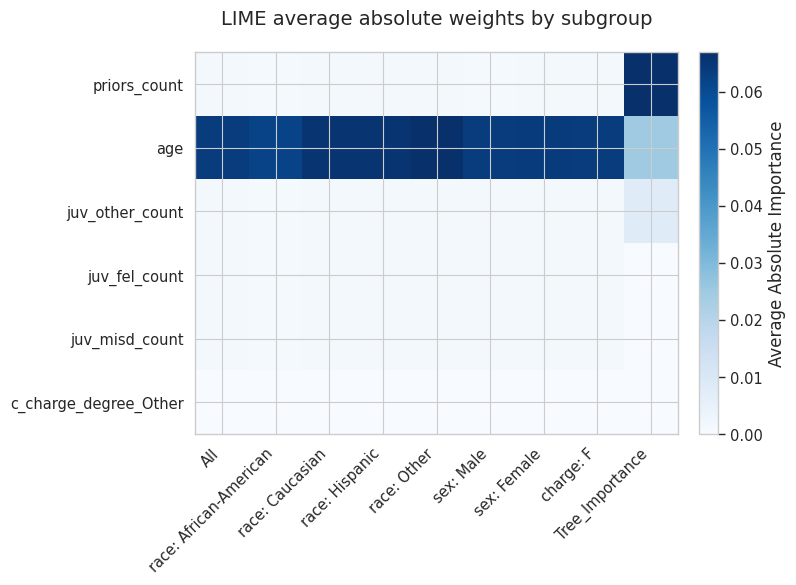

Heatmap data:


,All,race: African-American,race: Caucasian,race: Hispanic,race: Other,sex: Male,sex: Female,charge: F,Tree_Importance
priors_count,0.001051,0.000979,0.001212,0.001300,0.001409,0.001021,0.001257,0.001100,0.640818
age,0.063696,0.061663,0.065819,0.065605,0.066869,0.063652,0.063832,0.063595,0.236888
juv_other_count,0.001097,0.000971,0.001161,0.001290,0.001417,0.001062,0.001250,0.001127,0.076212
juv_fel_count,0.001089,0.000937,0.001169,0.001306,0.001444,0.001143,0.001201,0.001056,0.000000
juv_misd_count,0.001088,0.000946,0.001201,0.001272,0.001309,0.001081,0.001151,0.001066,0.000000
c_charge_degree_Other,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
# Heatmap of LIME average absolute weights by subgroup vs global tree importance
# Requires: X_test, feature_names, models_dict, lime_exp already defined

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os # Import the os module1
import re # Import the regex module

def _get_tree_model(models_dict):
    for k in ["racial_bias_dt"]:
        if k in models_dict:
            return models_dict[k], k
    # If none of the preferred keys are found, return the first tree-based model found
    for name, model in models_dict.items():
        if hasattr(model, "feature_importances_"):
            return model, name
    raise ValueError("No tree-based model found in models_dict")

def _predict_fn_df(model, feature_names):
    # Use the model's internal feature names if available, otherwise use the provided list
    model_feature_names = list(getattr(model, 'feature_names_in_', feature_names))

    def _fn(X):
        if isinstance(X, np.ndarray):
            # Ensure the DataFrame has the correct columns and order
            # Create DataFrame with the names LIME passes (using provided feature_names)
            X = pd.DataFrame(X, columns=feature_names)
            # Reindex to match model's expected features, adding missing columns with 0
            X = X.reindex(columns=model_feature_names, fill_value=0)
        elif isinstance(X, pd.DataFrame):
             # If already a DataFrame, just reindex
             X = X.reindex(columns=model_feature_names, fill_value=0)

        # Ensure column order matches the model's expected order before predicting
        X = X[model_feature_names]

        return model.predict_proba(X)
    return _fn


def compute_lime_avg_weights(X_subset, model, lime_exp, feature_names, sample_size=200, random_state=42):
    if len(X_subset) == 0:
        return np.zeros(len(feature_names))
    n = min(sample_size, len(X_subset))
    sample = X_subset.sample(n, random_state=random_state)
    avg = np.zeros(len(feature_names), dtype=float)
    predict_fn = _predict_fn_df(model, feature_names) # Use the updated predict_fn

    for row in sample.values:
        exp = lime_exp.explain_instance(row, predict_fn, num_features=len(feature_names))
        for feat, weight in exp.as_list():
            match = re.match(r'([a-zA-Z_]+)', feat)
            if match:
                fname = match.group(1)
                if fname in feature_names:
                    j = feature_names.index(fname)
                    avg[j] += abs(weight)
    return avg / n

def build_group_masks(X_test):
    groups = {}
    candidate_cols = [
        "race_African-American", "race_Caucasian", "race_Hispanic", "race_Other",
        "race_Asian", "race_Native American", "sex_Male", "sex_Female",
        "c_charge_degree_F", "c_charge_degree_M"
    ]
    for col in candidate_cols:
        if col in X_test.columns:
            mask = X_test[col] == 1
            if mask.sum() >= 30:
                groups[col] = mask
    # Ensure 'All' group is a Series with the correct index
    groups = {"All": pd.Series(True, index=X_test.index)} | groups
    return groups

def lime_importance_heatmap_clean(
    X_test, models_dict, lime_exp, feature_names,
    top_k=15, sample_size=300, random_state=42,
    exclude_prefixes=("race_", "sex_"),
    save_path="/mnt/data/lime_group_heatmap.png"
):
    model, model_key = _get_tree_model(models_dict)
    # Retrieve the feature names the model was trained on
    model_feature_names = list(getattr(model, 'feature_names_in_', feature_names))

    if not hasattr(model, "feature_importances_"):
        # If feature_importances_ is not available, try to compute it from the model
        if hasattr(model, 'estimators_') and isinstance(model.estimators_[0], xgb.XGBoost):
            # This is a multi-tree model like XGBoost, get importance from the first tree
            # Note: This is a simplification, true XGBoost importance is more complex
            print("Warning: Using feature_importances_ from the first tree in a multi-tree model.")
            tree_imp = np.asarray(model.feature_importances_, dtype=float)
        elif hasattr(model, 'tree_') and hasattr(model.tree_, 'compute_feature_importances'):
             # For scikit-learn DecisionTree
             tree_imp = np.asarray(model.feature_importances_, dtype=float)
        else:
             raise ValueError("Selected model lacks feature_importances_ and cannot compute it.")


    tree_imp = np.asarray(model.feature_importances_, dtype=float) # Use model's feature importances
    groups = build_group_masks(X_test)

    group_names = list(groups.keys())
    # Ensure the matrix uses the feature names that will be in the rows of the heatmap
    row_feature_names = _exclude_features(model_feature_names, exclude_prefixes=exclude_prefixes)
    mat = np.zeros((len(row_feature_names), len(group_names)), dtype=float)

    # Create a mapping from the full model feature names to the row feature names indices
    model_name_to_row_idx = {name: i for i, name in enumerate(row_feature_names)}

    for gi, gname in enumerate(group_names):
        mask = groups[gname]
        Xg = X_test[mask]
        # Compute LIME weights for all model features
        weights_all_features = compute_lime_avg_weights(
            X_subset=Xg,
            model=model,
            lime_exp=lime_exp,
            feature_names=model_feature_names, # Pass model feature names to compute_lime_avg_weights
            sample_size=sample_size,
            random_state=random_state
        )
        # Populate the matrix only for the row_feature_names
        for i, fname in enumerate(model_feature_names):
            if fname in row_feature_names:
                 mat[model_name_to_row_idx[fname], gi] = weights_all_features[i]


    # Filter tree importance to the row features
    model_name_to_idx = {name: i for i, name in enumerate(model_feature_names)}
    tree_imp_rows = np.array([tree_imp[model_name_to_idx[name]] for name in row_feature_names])


    # Pick top_k rows based on the filtered tree importance
    top_idx = np.argsort(-tree_imp_rows)[:min(top_k, len(row_feature_names))]
    features_top = [row_feature_names[i] for i in top_idx]
    mat_top = mat[top_idx, :]
    tree_imp_top = tree_imp_rows[top_idx]

    if mat_top.max() > 0:
        # Scale tree importance relative to the max LIME value in the top features
        scale = mat_top.max()
        # Avoid division by zero for scaling if all tree importances are zero
        if tree_imp_top.max() > 1e-12:
             ti_col = (tree_imp_top / tree_imp_top.max()) * scale
        else:
             ti_col = tree_imp_top * 0 # If tree importances are all zero, scaled importance is zero
    else:
        # If all LIME values are zero, set scaled tree importance to the raw tree importance
        ti_col = tree_imp_top


    mat_plot = np.concatenate([mat_top, ti_col.reshape(-1, 1)], axis=1)
    group_labels = [_pretty_group(k) if k != "All" else "All" for k in group_names] + ["Tree_Importance"]


    plt.figure(figsize=(max(7, (len(group_labels)) * 0.9), max(6, len(features_top) * 0.35)))
    im = plt.imshow(mat_plot, aspect="auto", cmap='Blues') # Use a standard colormap
    plt.colorbar(im, fraction=0.046, pad=0.04, label='Average Absolute Importance') # Add colorbar label
    plt.yticks(range(len(features_top)), features_top)
    plt.xticks(range(len(group_labels)), group_labels, rotation=45, ha="right") # Rotate x-axis labels
    plt.title("LIME average absolute weights by subgroup", pad=20) # Add padding to title
    plt.tight_layout()

    # Create directory if it doesn't exist
    save_dir = os.path.dirname(save_path)
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        print(f"Created directory: {save_dir}")

    try:
        plt.savefig(save_path, dpi=160, bbox_inches='tight') # Use bbox_inches='tight' to prevent labels from being cut off
        print(f"Saved heatmap to: {save_path}")
    except Exception as e:
        print(f"Error saving heatmap to {save_path}: {e}")


    plt.show()

    df = pd.DataFrame(mat_top, index=features_top, columns=[_pretty_group(k) if k != "All" else "All" for k in group_names])
    df["Tree_Importance"] = tree_imp_top
    return df, save_path

def _pretty_group(col):
    # Improve readability of subgroup column names
    col = col.replace("_", " ")
    col = col.replace("race ", "race: ")
    col = col.replace("sex ", "sex: ")
    col = col.replace("c charge degree ", "charge: ")
    return col

def _exclude_features(feature_names, exclude_prefixes=("race_", "sex_")):
    # Drop protected-attribute one-hots from the ROWS of the heatmap
    keep = []
    for f in feature_names:
        if any(f.startswith(p) for p in exclude_prefixes):
            continue
        keep.append(f)
    return keep
# -------------------- run --------------------

df_heatmap, heatmap_path = lime_importance_heatmap_clean(
    X_test=X_test,
    models_dict=models_dict,
    lime_exp=lime_exp,
    feature_names=feature_names, # Assuming feature_names is the list of all features after preprocessing
    top_k=15,
    sample_size=300,
    random_state=42,
    exclude_prefixes=("race_", "sex_"),  # keep sensitive one-hots out of the rows
    save_path="/mnt/data/lime_group_heatmap.png"
)

print(f"Heatmap data:")
display(df_heatmap.head(20))

Successfully loaded data with shape: (18316, 52)
Available columns in dataset: ['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1', 'start', 'end', 'event']

Preprocessing steps:
1. Handling missing values...
2. Converting categorical variables...

Verifying featur

/tmp/ipython-input-86841138.py:69: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


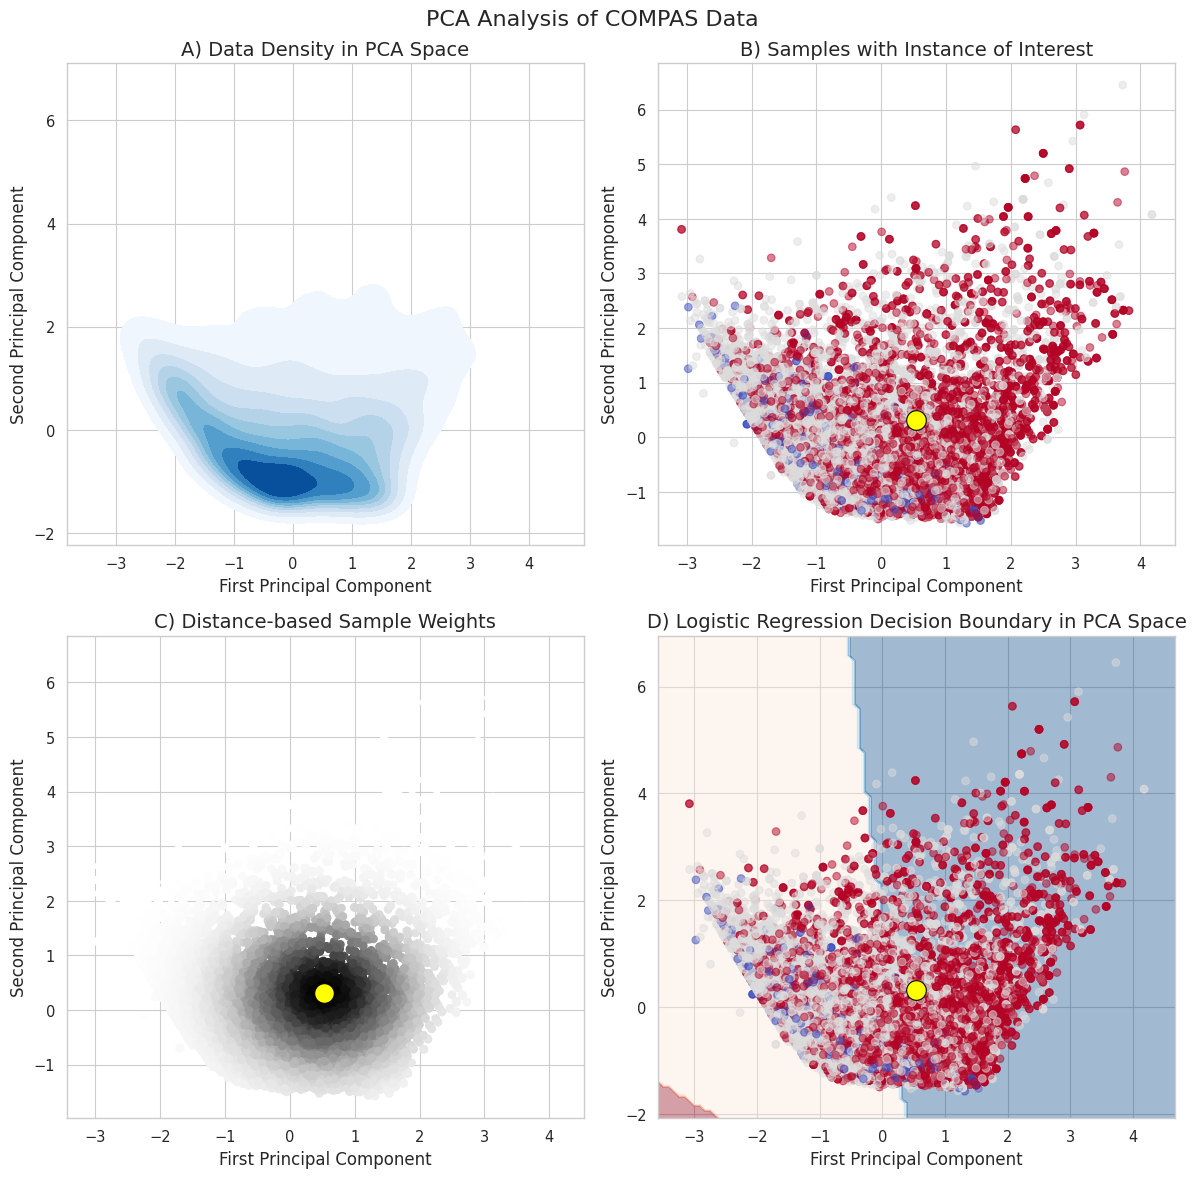


Explained variance ratio for first two components:
PC1: 0.3928 (39.3%)
PC2: 0.3015 (30.1%)


In [ ]:
# Load and preprocess the data
data = load_data()
train_data, test_data = preprocess_data(data)

# Get the training features and labels
X_train_scaled = train_data[0]
y_train = train_data[1]

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# Create a grid for the prediction surface
x1_min, x1_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
x2_min, x2_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100),
                      np.linspace(x2_min, x2_max, 100))

# Create figure with four subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('PCA Analysis of COMPAS Data', fontsize=16)

# A) Data Density in PCA Space
sns.kdeplot(data=pd.DataFrame(X_pca, columns=['PC1', 'PC2']),
            x='PC1', y='PC2', fill=True, cmap='Blues',
            ax=ax1)
ax1.set_title('A) Data Density in PCA Space')

# B) Instance of interest and samples
scatter = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train,
                     cmap='coolwarm', alpha=0.5, s=30)
# Highlight a random instance of interest
instance_idx = np.random.randint(len(X_pca))
ax2.scatter(X_pca[instance_idx, 0], X_pca[instance_idx, 1],
            color='yellow', s=200, marker='o', edgecolor='black')
ax2.set_title('B) Samples with Instance of Interest')

# C) Distance-based weights
distances = np.sqrt(np.sum((X_pca - X_pca[instance_idx])**2, axis=1))
weights = np.exp(-(distances**2)/2)
scatter = ax3.scatter(X_pca[:, 0], X_pca[:, 1], c=weights,
                     cmap='Greys', s=30)
ax3.scatter(X_pca[instance_idx, 0], X_pca[instance_idx, 1],
            color='yellow', s=200, marker='o', edgecolor='black')
ax3.set_title('C) Distance-based Sample Weights')

# D) Decision boundary visualization
# Train a simple model on PCA-transformed data to plot decision boundary
from sklearn.linear_model import LogisticRegression
model_pca = LogisticRegression(random_state=RANDOM_STATE)
model_pca.fit(X_pca, y_train)

# Predict on the grid points
grid_points = np.c_[xx1.ravel(), xx2.ravel()]
Z = model_pca.predict(grid_points)
Z = Z.reshape(xx1.shape)


# Plot decision boundary using the model's predictions on the grid
ax4.contourf(xx1, xx2, Z, alpha=0.4,
             cmap='RdBu')
ax4.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train,
                     cmap='coolwarm', alpha=0.5, s=30) # Plot original points
ax4.scatter(X_pca[instance_idx, 0], X_pca[instance_idx, 1],
            color='yellow', s=200, marker='o', edgecolor='black') # Highlight instance
ax4.set_title('D) Logistic Regression Decision Boundary in PCA Space')

# Common settings for all subplots
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlabel('First Principal Component')
    ax.set_ylabel('Second Principal Component')
    ax.grid(True)

plt.tight_layout()
plt.show()

# Print explained variance for first two components
print("\nExplained variance ratio for first two components:")
for i, var in enumerate(pca.explained_variance_ratio_, 1):
    print(f"PC{i}: {var:.4f} ({var*100:.1f}%)")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


PCA variance: PC1=39.3%, PC2=30.1%

Instance 1: test index 10735


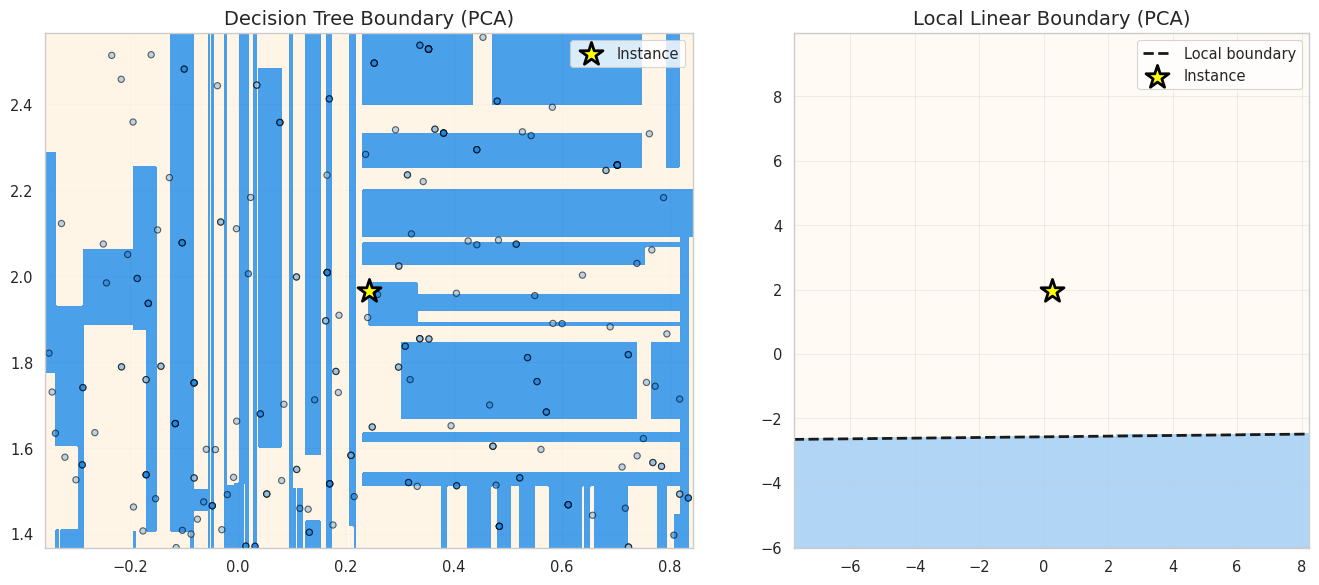


Instance 2: test index 16545


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


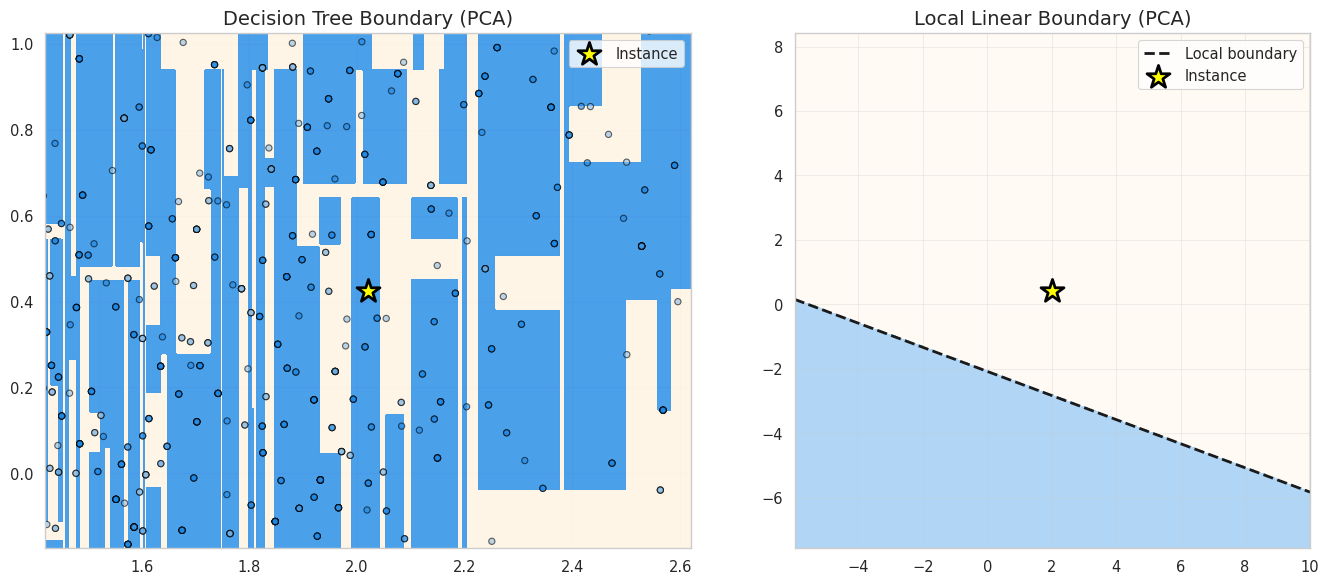

In [ ]:
import numpy as np, warnings
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from lime import lime_tabular

# Assumes: X_train, y_train, X_test, y_test, feature_names, RANDOM_STATE exist.

def _pick_interesting_idxs(X, model, k=3):
    p = model.predict_proba(X)[:,1]
    return np.argsort(np.abs(p-0.5))[:k]

def _plot_dt(ax, X_train_pca, y_train, xlim, ylim):
    xx, yy = np.meshgrid(np.linspace(*xlim, 400), np.linspace(*ylim, 400))
    Z = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_train_pca, y_train)\
        .predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    colors = ['#fff3e0', '#1e88e5']
    ax.contourf(xx, yy, Z, levels=[-0.5,0.5,1.5], colors=colors, alpha=0.8)
    ax.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train,
               cmap=LinearSegmentedColormap.from_list('custom', colors),
               edgecolor='black', alpha=0.6, s=20)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_title('Decision Tree Boundary (PCA)')
    ax.grid(True, alpha=0.3)

def _fit_local_logit_in_pca(model, pca, z_star, n=2000, radius=2.0):
    rng = np.random.RandomState(RANDOM_STATE)
    Z = z_star + rng.normal(size=(n,2)) * radius
    X = pca.inverse_transform(Z)
    y = model.predict(X)
    clf = LogisticRegression(random_state=RANDOM_STATE, solver='liblinear').fit(Z, y)
    return clf.coef_[0], clf.intercept_[0]

def _plot_linear_boundary(ax, w, b, z_star, xlim, ylim):
    a, c = float(w[0]), float(w[1])
    xs = np.array([xlim[0], xlim[1]])
    if abs(c) > 1e-12:
        ys = (-(a*xs) - b)/c
    else:
        xs = np.full(2, -b/a); ys = np.array(ylim)
    ax.plot(xs, ys, 'k--', linewidth=2, label='Local boundary')
    ax.scatter(*z_star, color='yellow', marker='*', s=300, edgecolor='black', linewidth=2, label='Instance')
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.3); ax.legend(loc='best')

def _shade_halfplane(ax, w, b, xlim, ylim):
    xx, yy = np.meshgrid(np.linspace(*xlim, 400), np.linspace(*ylim, 400))
    mask = (w[0]*xx + w[1]*yy + b) > 0   # 1=Recidivism side
    arr = mask.astype(int)               # numeric 0/1 for imshow
    cmap = ListedColormap(['#fff3e0', '#1e88e5'])
    ax.imshow(arr, extent=(xlim[0], xlim[1], ylim[0], ylim[1]),
              origin='lower', cmap=cmap, alpha=0.35, vmin=0, vmax=1, interpolation='nearest')

def _plot_local_panel(ax, model, pca, z_star, xlim, ylim, local_radius=2.0):
    w, b = _fit_local_logit_in_pca(model, pca, z_star, radius=local_radius)
    _shade_halfplane(ax, w, b, xlim, ylim)
    _plot_linear_boundary(ax, w, b, z_star, xlim, ylim)
    ax.set_title('Local Linear Boundary (PCA)')

def compare_instance(idx, X_test, y_test, model, pca, X_train_pca,
                     zoom_dt=1.8, zoom_lime=1.8, local_radius=2.0):
    x = X_test.iloc[idx].values
    z = pca.transform(x.reshape(1, -1))[0]
    xlim_dt  = (z[0]-zoom_dt,  z[0]+zoom_dt)
    ylim_dt  = (z[1]-zoom_dt,  z[1]+zoom_dt)
    xlim_lm  = (z[0]-zoom_lime, z[0]+zoom_lime)
    ylim_lm  = (z[1]-zoom_lime, z[1]+zoom_lime)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))
    _plot_dt(ax1, X_train_pca, y_train, xlim_dt, ylim_dt)
    ax1.scatter(*z, color='yellow', marker='*', s=300, edgecolor='black', linewidth=2, zorder=5, label='Instance')
    ax1.legend(loc='best')
    _plot_local_panel(ax2, model, pca, z, xlim_lm, ylim_lm, local_radius=local_radius)
    plt.tight_layout(); return fig

def analyze_instances(X_test, y_test, model, pca,
                      k=3, zoom_dt=1.8, zoom_lime=1.8, pick='interesting', local_radius=2.0):
    Xtr = X_train.values if hasattr(X_train, "values") else np.asarray(X_train)
    X_train_pca = pca.transform(Xtr)
    print(f"PCA variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
    idxs = _pick_interesting_idxs(X_test.values, model, k) if pick=='interesting' \
           else np.random.choice(len(X_test), size=k, replace=False)
    for r, idx in enumerate(idxs, 1):
        print(f"\nInstance {r}: test index {X_test.index[idx]}")
        compare_instance(idx, X_test, y_test, model, pca, X_train_pca,
                         zoom_dt=zoom_dt, zoom_lime=zoom_lime, local_radius=local_radius)
        plt.show()

# Train once here
dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_train, y_train)
pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_train)
explainer = lime_tabular.LimeTabularExplainer(  # not used for shading, kept if you still want tabular outputs elsewhere
    (X_train.values if hasattr(X_train, "values") else np.asarray(X_train)),
    feature_names=feature_names,
    class_names=['No Recidivism','Recidivism'],
    mode='classification',
    discretize_continuous=False
)

# Independent zooms; crisp linear boundary + numeric shading (no dtype errors)
# Now picks random instances each run instead of using fixed seed
analyze_instances(X_test, y_test, dt_model, pca2,
                  k=2, zoom_dt=0.6, zoom_lime=8.0, pick='random', local_radius=2.0)
